# Results Notebook

This Notebook contains the code for generating all figures and tables in the paper, using raw results from the experimaestro workspace.

# Imports and Utils

In [13]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# use ACM style

FONT_SIZE = 14
fig_dir = Path("./local/figures/mice")
# Set font for publication quality
# plt.rcParams['font.family'] = 'Times New Roman'
# 1. Configure Matplotlib for ACM Style
plt.rcParams.update(
    {
        "text.usetex": False,  # Set to True if you have LaTeX installed on your system
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Liberation Serif", "DejaVu Serif"],
        "font.size": 10,  # Standard ACM body text size is ~9-10pt
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 12,
    }
)
plt.style.use("ggplot")


# default_workspace_path
# ws = get_workspace().path
# xps_root = ws / "experiments"

xps_root = Path("/Users/victor/code/experiments/JZ")


def get_last_xp(xp_id, force_date=None, verbose=True) -> str:
    dates = sorted(list((xps_root / xp_id).glob("*")))
    if verbose: print(f"Found dates for {xp_id}: {[d.name for d in dates]}")

    # parse and get most recent date
    if force_date is not None:
        forced_date_path = xps_root / xp_id / force_date
        if forced_date_path in dates:
            if verbose: print(f"Using forced date for {xp_id}: {forced_date_path.name}")
            return forced_date_path
        else:
            if verbose: print(f"Forced date {force_date} not found for xp {xp_id}")

    dates = [d for d in dates if re.match(r"\d+_\d+", d.name)]

    last = "" 
    # last = max(dates, key=lambda d: d.name)
    for date in dates[::-1]:
        if (xps_root / xp_id / date / "results" / "results.csv").exists():
            last = date
            break


    if not last:
        print(f"No valid dates found for xp {xp_id}, returning dry-run")
        last = "dry-run"

    return xps_root / xp_id / last


def get_results(xp_path, verbose=True) -> pd.DataFrame:
    path = xp_path / "results"
    csv_files = list(path.glob("results.csv"))

    if len(csv_files):
        return pd.read_csv(csv_files[0])
    else:
        raise ValueError(f"no csv files found in {path}")


def process_results(results) -> pd.DataFrame:
    # labels1 = results.iloc[0]
    if "tag" in list(results.columns)[-1]:
        print("V1 xp -> Rerun to get new df format !")
        labels1 = results.iloc[0]
        labels2 = results.iloc[1]
        results = results.iloc[3:]
    else:
        labels1 = [l1.split('.')[0] for l1 in results.columns]
        labels2 = results.iloc[0]
        results = results.iloc[2:]

    labels = [
        f"{l1}{'_' + str(l2) if str(l2) != 'nan' else ''}"
        for l1, l2 in zip(labels1, labels2)
    ]
    
    labels[0] = "dataset"
    results.columns = labels
    # Select columns containing 'mean' or 'var' (case-insensitive)
    cols_to_convert = results.filter(regex="(?i)mean|var").columns

    #Convert those columns to numeric, turning errors (like 'None' strings) into NaN
    results[cols_to_convert] = results[cols_to_convert].apply(
        pd.to_numeric, errors="coerce"
    )

    return results


def get_aggregated_stats(results, group_cols, metrics):
    # 3. Ensure numeric types
    all_cols = []
    for m in metrics:
        all_cols.extend([f"{m}_mean", f"{m}_var"])

    for col in all_cols:
        results[col] = pd.to_numeric(results[col], errors="coerce")

    # 4. Compute the Simple Average of Means and Variances
    #    We do NOT add the inter-dataset variance here.
    #    We act as if the datasets are fixed strata.
    aggregated_stats = results.groupby(group_cols, dropna=False)[all_cols].mean()

    # 5. Rename columns for clarity
    #    Renaming 'AP_mean' -> 'Grand_Mean_AP' and 'AP_var' -> 'Average_Var_AP'
    rename_dict = {}
    for m in metrics:
        rename_dict[f"{m}_mean"] = f"{m}_Grand_Mean"
        rename_dict[f"{m}_var"] = f"{m}_Average_Var"

    aggregated_stats = aggregated_stats.rename(columns=rename_dict)

    return aggregated_stats
    # Add experiment label


def get_aggregated_df(df, datasets, name):
    """
    Returns a NEW DataFrame with aggregated means for specific datasets.
    Does not modify the original df.
    """
    # 1. Identify metric columns and metadata columns
    metric_cols = df.filter(regex="(?i)mean|var").columns.tolist()
    # Metadata columns are everything EXCEPT the metrics and the dataset name
    metadata_cols = [c for c in df.columns if c not in metric_cols and c != "dataset"]

    # 2. Filter rows for the specified datasets
    subset = df[df["dataset"].isin(datasets)].copy()
    subset[metric_cols] = subset[metric_cols].apply(pd.to_numeric, errors="coerce")

    # 3. Group by ALL metadata columns to preserve them
    # This keeps 'base', 'loss', 'scorer', 'arch', etc. intact
    new_df = subset.groupby(metadata_cols, as_index=False)[metric_cols].mean()

    # 4. Assign the new dataset aggregate name
    new_df["dataset"] = name

    # Reorder for readability: dataset first, then metadata, then metrics
    cols = ["dataset"] + metadata_cols + metric_cols
    return new_df[cols]


print(f"found xps in {xps_root}")
all_xps = list(xps_root.glob("*"))
for xp in sorted(all_xps):
    print(f"- {xp.name}")

found xps in /Users/victor/code/experiments/JZ
- RankDistiLLMNeg_base
- RankDistiLLMNeg_mini
- baseline_MiniLM_CE
- baseline_mores
- baseline_small_CE
- baseline_small_CE_withruns
- colbertNeg_base
- colbertNeg_infoNCE_precision
- colbertNeg_mini
- comparison_precision
- core_base
- core_base_deberta
- core_base_deberta_top100
- core_base_ettin
- core_base_ettin_1b
- core_base_ettin_1b_bs=16
- core_base_ettin_scaling
- core_base_ettin_scaling_except_1b
- core_base_paper
- core_mini
- core_mini_debug
- cross_scorer_evaluation
- cross_scorer_evaluation_debug
- debug_CE_training
- debug_mice_plaid
- debug_mice_training
- eval_masked_step0
- eval_scorer_debug
- eval_scorer_top100
- eval_scorer_top1000
- hyperparams_search_contrastive
- local_model_evaluation
- reproduction_RankDistiLLM
- train_mice_bert_l4+3
- train_mice_bert_l48+3
- train_mice_ettin17_lX+3
- train_mice_ettin32_lX+3
- train_mice_ettin68_lX+3
- train_mice_ettin_150m
- train_mice_ettin_17m
- train_mice_ettin_17m-l3+X
- train

### Labeling

In [14]:
from format import loss_names, backbone_names, DATASET_TO_ABB, aggregations

ignore_losses = ["infoNCE_norm_size=True"]

# Main Figures

## Mice-$\ell$ Y+X

### Loading

In [15]:
# Main table
import pandas as pd

xps = {
    "train_mice_miniLM_l4+X": r"Mice MiniLM-$\ell$4+X",
    "train_mice_ettin_17m-l3+X": r"Mice Ettin-17m-$\ell$3+X",
    "train_mice_ettin_32m-l6+X": r"Mice Ettin-32m-$\ell$6+X",
}

def get_xp_df(xp):
    xp_path = xps_root / xp / "dry-run"
    xp_path = xps_root / xp
    xp_path = get_last_xp(xp_path)
    print(f"Using xp path: {xp_path}")
    df = process_results(get_results(xp_path))

    datasets = df["dataset"].unique()
    print(f"{len(datasets)} unique datasets : {list(datasets)}")
    # print(f"unique losses : {list(df['loss'].unique())}")
    # print(f"Backbones : {list(df['base'].unique())}")

    display(df.head())
    return df

xp_dfs = {xp: get_xp_df(xp) for xp in xps.keys()}

Found dates for /Users/victor/code/experiments/JZ/train_mice_miniLM_l4+X: ['20260511_190322', '20260512_104628', '20260512_105439', '20260512_110152', '20260512_221517', '20260515_082537', 'current', 'dry-run', 'lock']
Using xp path: /Users/victor/code/experiments/JZ/train_mice_miniLM_l4+X/20260515_082537
5 unique datasets : ['In Domain', 'mean', 'msmarco_dev', 'trec2019', 'trec2020']


,dataset,base,first_stage,n_interaction_layers,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var
2,In Domain,microsoft/MiniLM-L12-H384-uncased,bm25,1.0,0.756756,0.000010,0.826467,1.816459e-05,0.613600,1.067686e-06,0.602756,2.870410e-07
3,In Domain,microsoft/MiniLM-L12-H384-uncased,bm25,2.0,0.753378,0.000004,0.833944,1.078783e-04,0.616911,7.407074e-06,0.607122,9.959185e-07
4,In Domain,microsoft/MiniLM-L12-H384-uncased,bm25,3.0,0.764144,0.000004,0.844133,1.386999e-05,0.625155,6.781769e-07,0.611256,5.747773e-07
5,In Domain,microsoft/MiniLM-L12-H384-uncased,bm25,4.0,0.763533,0.000002,0.846745,5.514589e-07,0.624856,9.206986e-06,0.613400,2.063339e-06
6,In Domain,microsoft/MiniLM-L12-H384-uncased,bm25,5.0,0.761989,0.000011,0.847200,3.410958e-07,0.626067,1.341788e-05,0.614656,2.038089e-06


Found dates for /Users/victor/code/experiments/JZ/train_mice_ettin_17m-l3+X: ['20260514_145206', '20260515_081926', 'current', 'lock']
Using xp path: /Users/victor/code/experiments/JZ/train_mice_ettin_17m-l3+X/20260515_081926
5 unique datasets : ['In Domain', 'mean', 'msmarco_dev', 'trec2019', 'trec2020']


,dataset,base,first_stage,n_interaction_layers,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var
2,In Domain,jhu-clsp/ettin-encoder-17m,bm25,1.0,0.703645,0.000173,0.801778,0.000074,0.556067,0.000002,0.550789,0.000020
3,In Domain,jhu-clsp/ettin-encoder-17m,bm25,2.0,0.713967,0.000220,0.806489,0.000015,0.564022,0.000030,0.556022,0.000023
4,In Domain,jhu-clsp/ettin-encoder-17m,bm25,3.0,0.713800,0.000026,0.812400,0.000134,0.565822,0.000001,0.559422,0.000003
5,In Domain,jhu-clsp/ettin-encoder-17m,bm25,4.0,0.720956,0.000011,0.811400,0.000002,0.570256,0.000005,0.561833,0.000003
6,mean,NaN,bm25,NaN,0.620067,NaN,0.716733,NaN,0.405833,NaN,0.405767,NaN


Found dates for /Users/victor/code/experiments/JZ/train_mice_ettin_32m-l6+X: ['20260514_153256', '20260515_082500', 'current', 'lock']
Using xp path: /Users/victor/code/experiments/JZ/train_mice_ettin_32m-l6+X/20260515_082500
5 unique datasets : ['In Domain', 'mean', 'msmarco_dev', 'trec2019', 'trec2020']


,dataset,base,first_stage,n_interaction_layers,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var
2,In Domain,jhu-clsp/ettin-encoder-32m,bm25,1.0,0.763089,0.000008,0.842122,0.000014,0.612800,9.644255e-07,0.597900,1.071083e-06
3,In Domain,jhu-clsp/ettin-encoder-32m,bm25,2.0,0.759644,0.000074,0.838022,0.000033,0.610778,1.837163e-05,0.597989,1.902489e-05
4,In Domain,jhu-clsp/ettin-encoder-32m,bm25,3.0,0.754167,0.000012,0.842711,0.000019,0.611222,7.244687e-06,0.600022,6.184809e-06
5,In Domain,jhu-clsp/ettin-encoder-32m,bm25,4.0,0.752722,0.000005,0.839678,0.000037,0.614444,2.896023e-06,0.599222,8.926460e-08
6,mean,NaN,bm25,NaN,0.620067,NaN,0.716733,NaN,0.405833,NaN,0.405767,NaN


### Plotting

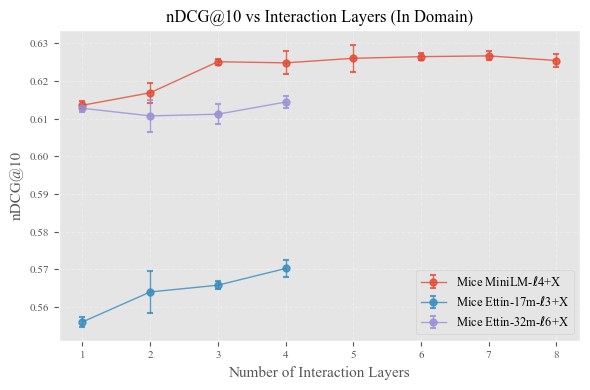

In [16]:
#filter 'n_contextualization_layers' is not null
metric = "nDCG@10"
metric_mean = f"{metric}_mean"
metric_var = f"{metric}_var"
y_key = "n_interaction_layers"

# Plot for each dataset
for dataset_name in ["In Domain"]:
    # Create figure with publication quality
    fig, ax = plt.subplots(figsize=(6, 4))
    max_y = 1
    for xp, df in xp_dfs.items():
        # plot nDCG@10_mean /pm nDCG@10_var as a function of n_contextualization_layers
        df[y_key] = pd.to_numeric(df[y_key], errors="coerce")
        df[metric_mean] = pd.to_numeric(df[metric_mean], errors="coerce")
        df[metric_var] = pd.to_numeric(df[metric_var], errors="coerce")
        df = df[df[y_key].notnull()]
        dataset_df = df[df["dataset"] == dataset_name].copy()
        max_y = max(max_y, int(max(df[y_key].unique())))
        if len(dataset_df) == 0:
            print(f"No data found for dataset: {dataset_name}")
            continue
        
        # Group by n_interaction_layers and compute aggregated statistics
        grouped = dataset_df.groupby(y_key, dropna=False).agg(
            mean_nDCG=(metric_mean, "mean"),
            std_nDCG=(metric_var, lambda x: np.sqrt(x.mean())),  # sqrt of mean variance
            count=(metric_mean, "count")
        ).reset_index()

        grouped = grouped.sort_values(y_key)

        ax.errorbar(
            grouped[y_key],
            grouped["mean_nDCG"],
            yerr=grouped["std_nDCG"],
            fmt="o-",
            markersize=5,
            linewidth=1,
            capsize=2,
            capthick=1.5,
            # color="#1f77b4",
            # ecolor="#1f77b4",
            alpha=0.8,
            label=f"{xps[xp]}"
        )

    # Formatting
    ax.set_xlabel("Number of Interaction Layers", fontsize=11, fontweight="normal")
    ax.set_ylabel("nDCG@10", fontsize=11, fontweight="normal")
    ax.set_title(f"{metric} vs Interaction Layers ({dataset_name})", fontsize=12, fontweight="normal")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(frameon=True, loc="best", fontsize=9)
    ax.set_xticks(list(range(1,max_y+1)))
    # ax.set_ylim(.50, .512)  # nDCG is between 0 and 1
    plt.tight_layout()
    plt.savefig(fig_dir / f"nDCG10_vs_InteractionLayers_{dataset_name.replace(' ', '_')}.pdf")
    plt.show()
    # Display grouped results
    # print(f"\nAggregated nDCG@10 Statistics by Contextualization Layers ({dataset_name}):")
    # display(grouped)

## Mice X+3

### Loading

In [20]:
# Main table
import pandas as pd

xps = {
    "train_mice_miniLM_lX+3": "Mice MiniLM-lX+3",
    "train_mice_ettin68_lX+3": "Mice Ettin-68m-lX+3",
    "train_mice_ettin32_lX+3": "Mice Ettin-32m-lX+3",
    "train_mice_ettin17_lX+3": "Mice Ettin-17m-lX+3",
}

def get_xp_df(xp):
    xp_path = xps_root / xp / "dry-run"
    xp_path = xps_root / xp
    xp_path = get_last_xp(xp_path)
    print(f"Using xp path: {xp_path}")
    df = process_results(get_results(xp_path))

    datasets = df["dataset"].unique()
    print(f"{len(datasets)} unique datasets : {list(datasets)}")
    # print(f"unique losses : {list(df['loss'].unique())}")
    # print(f"Backbones : {list(df['base'].unique())}")

    display(df.head())
    return df

xp_dfs = {xp: get_xp_df(xp) for xp in xps.keys()}

Found dates for /Users/victor/code/experiments/JZ/train_mice_miniLM_lX+3: ['20260424_143839', '20260425_161300', '20260512_215807', '20260513_085811', '20260513_093201', '20260515_093820', 'current', 'lock']
Using xp path: /Users/victor/code/experiments/JZ/train_mice_miniLM_lX+3/20260513_093201
V1 xp -> Rerun to get new df format !
5 unique datasets : ['In Domain', 'mean', 'msmarco_dev', 'trec2019', 'trec2020']


,dataset,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var,base,first_stage,n_contextualization_layers
3,In Domain,0.728078,0.000001,0.822467,1.366335e-05,0.558767,6.601004e-06,0.557944,1.067045e-06,microsoft/MiniLM-L12-H384-uncased,bm25,0
4,In Domain,0.737978,0.000020,0.826256,2.223799e-06,0.583822,9.971361e-06,0.580033,4.407645e-06,microsoft/MiniLM-L12-H384-uncased,bm25,1
5,In Domain,0.754122,0.000004,0.840767,6.300482e-07,0.601944,1.107792e-05,0.595111,7.071646e-06,microsoft/MiniLM-L12-H384-uncased,bm25,2
6,In Domain,0.758422,0.000009,0.839556,1.444606e-05,0.613967,1.181150e-06,0.603267,1.877712e-07,microsoft/MiniLM-L12-H384-uncased,bm25,3
7,In Domain,0.764144,0.000004,0.844133,1.386999e-05,0.625155,6.781769e-07,0.611256,5.747773e-07,microsoft/MiniLM-L12-H384-uncased,bm25,4


Found dates for /Users/victor/code/experiments/JZ/train_mice_ettin68_lX+3: ['20260513_093057', 'current', 'lock']
Using xp path: /Users/victor/code/experiments/JZ/train_mice_ettin68_lX+3/20260513_093057
V1 xp -> Rerun to get new df format !
5 unique datasets : ['In Domain', 'mean', 'msmarco_dev', 'trec2019', 'trec2020']


,dataset,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var,base,first_stage,n_contextualization_layers
3,In Domain,0.700089,0.000004,0.792145,1.250469e-05,0.525122,4.022637e-06,0.520889,1.899363e-05,jhu-clsp/ettin-encoder-68m,bm25,0
4,In Domain,0.719967,0.000051,0.814022,1.326251e-05,0.581156,6.414800e-07,0.575655,2.003811e-07,jhu-clsp/ettin-encoder-68m,bm25,1
5,In Domain,0.765989,0.000008,0.840867,1.275461e-05,0.627889,4.695859e-06,0.619056,1.160352e-06,jhu-clsp/ettin-encoder-68m,bm25,10
6,In Domain,0.765867,0.000018,0.843844,7.705554e-08,0.630178,4.692238e-07,0.623389,1.067045e-06,jhu-clsp/ettin-encoder-68m,bm25,11
7,In Domain,0.758722,0.000035,0.844989,1.892582e-07,0.630178,1.170198e-07,0.621289,2.273716e-06,jhu-clsp/ettin-encoder-68m,bm25,12


Found dates for /Users/victor/code/experiments/JZ/train_mice_ettin32_lX+3: ['20260513_181220', '20260515_093149', 'current']
Using xp path: /Users/victor/code/experiments/JZ/train_mice_ettin32_lX+3/20260515_093149
5 unique datasets : ['In Domain', 'mean', 'msmarco_dev', 'trec2019', 'trec2020']


,dataset,base,first_stage,n_contextualization_layers,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var
2,In Domain,jhu-clsp/ettin-encoder-32m,bm25,0.0,0.683889,0.000158,0.788456,2.058056e-05,0.510733,0.000012,0.506489,0.000001
3,In Domain,jhu-clsp/ettin-encoder-32m,bm25,1.0,0.717511,0.000037,0.794533,1.505323e-05,0.572111,0.000015,0.563611,0.000002
4,In Domain,jhu-clsp/ettin-encoder-32m,bm25,2.0,0.730922,0.000048,0.825289,1.571812e-05,0.586289,0.000006,0.580033,0.000002
5,In Domain,jhu-clsp/ettin-encoder-32m,bm25,3.0,0.748189,0.000005,0.838556,7.881166e-07,0.602622,0.000017,0.596433,0.000006
6,In Domain,jhu-clsp/ettin-encoder-32m,bm25,4.0,0.754867,0.000014,0.840489,1.215900e-06,0.600700,0.000005,0.587356,0.000006


Found dates for /Users/victor/code/experiments/JZ/train_mice_ettin17_lX+3: ['20260515_093300', '20260515_100815', '20260518_184443', 'current', 'dry-run']
Using xp path: /Users/victor/code/experiments/JZ/train_mice_ettin17_lX+3/20260518_184443
5 unique datasets : ['In Domain', 'mean', 'msmarco_dev', 'trec2019', 'trec2020']


,dataset,base,first_stage,n_contextualization_layers,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var
2,In Domain,jhu-clsp/ettin-encoder-17m,bm25,0.0,0.656611,0.000059,0.767533,2.541766e-05,0.482733,0.000008,0.477367,0.000016
3,In Domain,jhu-clsp/ettin-encoder-17m,bm25,1.0,0.697511,0.000036,0.804589,5.003833e-07,0.538000,0.000011,0.529144,0.000003
4,In Domain,jhu-clsp/ettin-encoder-17m,bm25,2.0,0.694800,0.000093,0.797600,1.456315e-04,0.541033,0.000025,0.536344,0.000005
5,In Domain,jhu-clsp/ettin-encoder-17m,bm25,3.0,0.713800,0.000026,0.812400,1.335512e-04,0.565822,0.000001,0.559422,0.000003
6,In Domain,jhu-clsp/ettin-encoder-17m,bm25,4.0,0.707022,0.000064,0.811200,1.174771e-05,0.551733,0.000004,0.542744,0.000020


### Plotting


Aggregated nDCG@10 Statistics by Contextualization Layers (In Domain):


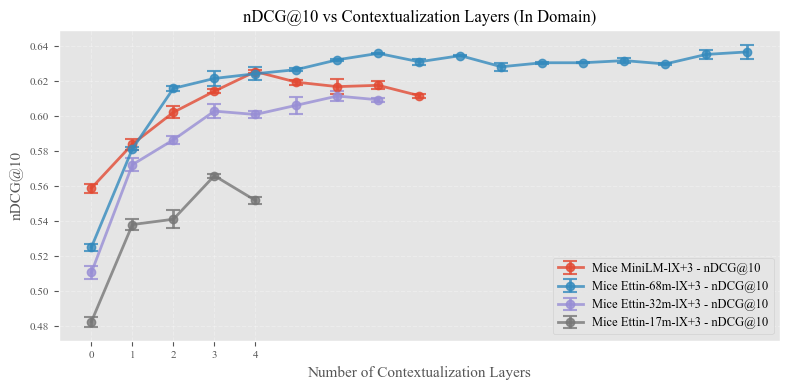

In [21]:
#filter 'n_contextualization_layers' is not null
metric = "nDCG@10"
metric_mean = f"{metric}_mean"
metric_var = f"{metric}_var"
figsize=(8, 4)

# Plot for each dataset
for dataset_name in ["In Domain"]:
    # Create figure with publication quality
    fig, ax = plt.subplots(figsize=figsize)

    for xp, df in xp_dfs.items():
        # plot nDCG@10_mean /pm nDCG@10_var as a function of n_contextualization_layers
        df["n_contextualization_layers"] = pd.to_numeric(df["n_contextualization_layers"], errors="coerce")
        df[metric_mean] = pd.to_numeric(df[metric_mean], errors="coerce")
        df[metric_var] = pd.to_numeric(df[metric_var], errors="coerce")
        df = df[df["n_contextualization_layers"].notnull()]
        dataset_df = df[df["dataset"] == dataset_name].copy()
        if len(dataset_df) == 0:
            print(f"No data found for dataset: {dataset_name}")
            continue
        
        # Group by n_contextualization_layers and compute aggregated statistics
        grouped = dataset_df.groupby("n_contextualization_layers", dropna=False).agg(
            mean_nDCG=(metric_mean, "mean"),
            std_nDCG=(metric_var, lambda x: np.sqrt(x.mean())),  # sqrt of mean variance
            count=(metric_mean, "count")
        ).reset_index()

        grouped = grouped.sort_values("n_contextualization_layers")

        ax.errorbar(
            grouped["n_contextualization_layers"],
            grouped["mean_nDCG"],
            yerr=grouped["std_nDCG"],
            fmt="o-",
            markersize=6,
            linewidth=2,
            capsize=5,
            capthick=1.5,
            # color="#1f77b4",
            # ecolor="#1f77b4",
            alpha=0.8,
            label=f"{xps[xp]} - {metric}"
        )

    # Formatting
    ax.set_xlabel("Number of Contextualization Layers", fontsize=11, fontweight="normal")
    ax.set_ylabel("nDCG@10", fontsize=11, fontweight="normal")
    ax.set_title(f"{metric} vs Contextualization Layers ({dataset_name})", fontsize=12, fontweight="normal")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(frameon=True, loc="best", fontsize=9)
    ax.set_xticks(grouped["n_contextualization_layers"].unique())
    # ax.set_ylim(.50, .512)  # nDCG is between 0 and 1
    plt.tight_layout()
    print(f"\nAggregated nDCG@10 Statistics by Contextualization Layers ({dataset_name}):")
    plt.savefig(fig_dir / f"nDCG10_vs_ContextLayers_{dataset_name.replace(' ', '_')}.pdf")
    plt.show()
    # Display grouped results
        # display(grouped)

# Table Mice Results


## Loading

In [19]:
# Main table
import pandas as pd


# Configuration
metric = "nDCG@10"

datasets_to_keep = aggregations["In Domain"] + aggregations["BEIR13"] + ["In Domain", "BEIR13"]

xps = {
    # baselines
    "baseline_small_CE": "Baseline",
    "baseline_mores": "Mores-MiniLM-l8+4",
    # Mice Models
    "train_mice_miniLM_l4": "Mice-MiniLM-l4+3",
    "train_mice_ettin_68m": "Mice-Ettin-68M-l8+3",
    "train_mice_ettin_32m": "Mice-Ettin-32M-l8+3",
    "train_mice_ettin_17m": "Mice-Ettin-17M-l3+3",
    # "train_mice_ettin_150m": "test",
}

def get_xp_df(xp):
    xp_path = xps_root / xp / "dry-run"
    xp_path = xps_root / xp
    xp_path = get_last_xp(xp_path)
    print(f"Using xp path: {xp_path}")
    df = process_results(get_results(xp_path, verbose=False))

    datasets = df["dataset"].unique()
    backbones = list(df['base'].unique())
    print(f" - {len(datasets)} unique datasets : {list(datasets)}")
    print(f" - {len(backbones)} unique backbones : {backbones}")
    # print(f"unique losses : {list(df['loss'].unique())}")

    return df

xp_dfs = {xp: get_xp_df(xp) for xp in xps.keys()}

Found dates for /Users/victor/code/experiments/JZ/baseline_small_CE: ['.DS_Store', '20260428_093714', '20260428_185727', '20260429_150025', '20260430_112724', '20260430_113205', '20260430_121822', '20260504_182428', '20260511_181552', '20260512_220506', '20260513_085602', '20260514_145145', '20260514_145549', '20260515_083354', 'current', 'dry-run', 'lock']
Using xp path: /Users/victor/code/experiments/JZ/baseline_small_CE/20260515_083354
 - 27 unique datasets : ['BEIR13', 'In Domain', 'Lotte-S', 'arguana', 'climate_fever', 'dbpedia', 'fever', 'fiqa', 'hotpotqa', 'lotte_lifestyle', 'lotte_recreation', 'lotte_science', 'lotte_technology', 'lotte_writing', 'mean', 'minified', 'msmarco_dev', 'nfcorpus', 'nq', 'quora', 'robust04', 'scidocs', 'scifact', 'touche', 'trec2019', 'trec2020', 'trec_covid']
 - 5 unique backbones : ['jhu-clsp/ettin-encoder-17m', 'jhu-clsp/ettin-encoder-32m', 'jhu-clsp/ettin-encoder-68m', 'microsoft/MiniLM-L12-H384-uncased', nan]
Found dates for /Users/victor/code/e

KeyError: 'base'

## Processing

### Aggregation

In [ ]:
from format import loss_names, backbone_names, DATASET_TO_ABB, aggregations

metric_mean = f"{metric}_mean"
metric_var = f"{metric}_var"
cols_to_keep = ["dataset", "base", metric_mean, metric_var]
aggregated_df = []
models = set()

for xp_name, df in xp_dfs.items():
    # 1. drop rows where 'base' is null
    df = df.dropna(subset=["base"])[cols_to_keep]
    df_models = list(df["base"].unique())
    for model in df_models:
        name = (
            "baseline " + backbone_names.get(model, model)
            if "Baseline" in xps[xp_name]
            else xps[xp_name]
        )
        # build row for aggregated df
        row = {
            "Re-Ranker": name,
        }
        for dataset in datasets_to_keep:
            dataset_label = DATASET_TO_ABB.get(dataset, dataset)
            var_label = f"{dataset_label}_var"
            dataset_df = df[df["dataset"] == dataset]
            if len(dataset_df) == 0:
                print(f"No data for model {model} on dataset {dataset}")
                row[dataset_label] = np.nan
                row[var_label] = np.nan
            else:
                row[dataset_label] = dataset_df[metric_mean].values[0]
                row[var_label] = dataset_df[metric_var].values[0]

        aggregated_df.append(row)

aggregated_df = pd.DataFrame(aggregated_df)

display(aggregated_df)

,Re-Ranker,MSM,MSM_var,DL19,DL19_var,DL20,DL20_var,Ar,Ar_var,CF,...,SF,SF_var,T-v2,T-v2_var,T-C,T-C_var,In Domain,In Domain_var,BEIR13,BEIR13_var
0,baseline Ettin-17M,0.396633,3.333496e-07,0.686067,0.000006,0.670567,0.000157,0.150133,0.000105,0.224633,...,0.663067,4.424302e-05,0.261633,0.000028,0.727667,0.000129,0.584422,1.309013e-05,0.443490,4.542048e-05
1,baseline Ettin-32M,0.396633,3.333496e-07,0.686067,0.000006,0.670567,0.000157,0.150133,0.000105,0.224633,...,0.663067,4.424302e-05,0.261633,0.000028,0.727667,0.000129,0.584422,1.309013e-05,0.443490,4.542048e-05
2,baseline Ettin-68M,0.396633,3.333496e-07,0.686067,0.000006,0.670567,0.000157,0.150133,0.000105,0.224633,...,0.663067,4.424302e-05,0.261633,0.000028,0.727667,0.000129,0.584422,1.309013e-05,0.443490,4.542048e-05
3,baseline MiniLM-L12 (33M),0.396633,3.333496e-07,0.686067,0.000006,0.670567,0.000157,0.150133,0.000105,0.224633,...,0.663067,4.424302e-05,0.261633,0.000028,0.727667,0.000129,0.584422,1.309013e-05,0.443490,4.542048e-05
4,Mores-MiniLM-l8+4,0.434733,1.203337e-06,0.720233,0.000039,0.700733,0.000012,0.291100,0.000039,0.257900,...,0.697067,1.703348e-06,0.293867,0.000013,0.716200,0.000006,0.618567,8.074389e-06,0.486438,1.427684e-07
5,Mice-MiniLM-l4+3,0.432233,3.633183e-07,0.734233,0.000012,0.709000,0.000002,0.355867,0.000571,0.245867,...,0.692433,4.134332e-05,0.317333,0.000023,0.719767,0.000035,0.625155,6.781769e-07,0.497279,1.093393e-05
6,Mice-Ettin-68M-l8+3,0.446667,2.403277e-06,0.720467,0.000002,0.725033,0.000010,0.279967,0.000114,0.242800,...,0.708467,4.934007e-07,0.266933,0.000044,0.772667,0.000039,0.630722,2.629365e-06,0.495559,5.593316e-08
7,Mice-Ettin-32M-l8+3,0.427033,2.123331e-06,0.706467,0.000006,0.700167,0.000029,0.296333,0.000724,0.232233,...,0.700433,4.223346e-06,0.245433,0.000026,0.729200,0.000050,0.611222,7.244687e-06,0.473551,2.488288e-05


### Statistical tests
for each dataset and each metric, comparing each model to the baseline

## Write final latex table 

In [ ]:

aggregation_keys = ["MiniLM", "Ettin-17M", "Ettin-32M","Ettin-68M"]
#filter "var" columns
var_cols = [col for col in aggregated_df.columns if col.endswith("_var")]
aggregated_df = aggregated_df.drop(columns=var_cols)

def assign_reranker_type(name):
    for aggregation_key in aggregation_keys:
        if aggregation_key.lower() in name.lower():
            return aggregation_key
    return "Other"
# 1. Assign the Re-Ranker Type
aggregated_df["Re-Ranker Type"] = aggregated_df["Re-Ranker"].apply(assign_reranker_type)

# 2. Enforce "Re-Ranker Type" order based on your Aggregation_keys list
# We add "Other" at the end to catch any fallbacks
ordered_type_keys = aggregation_keys + ["Other"]
aggregated_df["Re-Ranker Type"] = pd.Categorical(
    aggregated_df["Re-Ranker Type"], 
    categories=ordered_type_keys, 
    ordered=True
)

# 3. Enforce "Re-Ranker" custom order (Alphabetical, but "mice" models at the bottom)
# Get a unique list of all Re-Rankers present in the data
unique_rerankers = aggregated_df["Re-Ranker"].unique()

# Split them into two groups: standard models and "mice" models
no_mice_models = sorted([m for m in unique_rerankers if "mice" not in m.lower()])
mice_models = sorted([m for m in unique_rerankers if "mice" in m.lower()])

# Combine them back (Standard sorted alphabetically + Mice sorted alphabetically)
ordered_reranker_keys = no_mice_models + mice_models

aggregated_df["Re-Ranker"] = pd.Categorical(
    aggregated_df["Re-Ranker"], 
    categories=ordered_reranker_keys, 
    ordered=True
)

# 4. Set the MultiIndex and Sort
dataset_cols = [DATASET_TO_ABB.get(d, d) for d in datasets_to_keep]

# Setting the index and sorting will now respect the categorical orders we just defined
pivot_df = (
    aggregated_df.set_index(["Re-Ranker Type", "Re-Ranker"])[dataset_cols]
    .sort_index(level=[0, 1])  # Sorts outer level, then inner level
)

def format_grouped_cells(df, dataset_cols):
    """
    Formats the DataFrame cells:
    - Bolds the maximum value per dataset column *within each Re-Ranker Type group*.
    - Formats all numbers to 3 decimal places.
    """
    # Create a copy to store the formatted string representations
    formatted_df = df.copy().astype(str)
    
    for col in dataset_cols:
        # Group by the outer index (Re-Ranker Type) and find the max value for this column
        # transform('max') broadcasts the maximum value to every row in that group
        group_maxes = df[col].groupby(level=0, group_keys=False).transform('max')
        
        # Build the formatted string for each row in the column
        new_col_values = []
        for val, g_max in zip(df[col], group_maxes):
            if pd.isna(val):
                new_col_values.append("-")  # Handle missing data gracefully
                continue
                
            val_str = f"{100*val:.1f}"  # Format as percentage with 3 decimals
            
            # Check if this value is the maximum within its Re-Ranker Type group
            if val == g_max:
                val_str = f"\\textbf{{{val_str}}}"
                
            new_col_values.append(val_str)
            
        formatted_df[col] = new_col_values
        
    return formatted_df

# --- How to apply it in your script ---

# 1. Get your list of dataset columns
dataset_cols = [DATASET_TO_ABB.get(d, d) for d in datasets_to_keep]

# 2. Generate the styled DataFrame by passing the entire pivot_df
styled_df = format_grouped_cells(pivot_df, dataset_cols)

# 3. Proceed to your .to_latex() block using styled_df2

display(styled_df)

# We use styled_df for to_latex, but escape=False is crucial 
# so LaTeX commands aren't escaped to \textbackslash
latex_output = styled_df.to_latex(
    multicolumn=True,
    multirow=True,
    caption="Evaluation Results. Shading: \\colorbox{red!15}{red} above median, \\colorbox{blue!15}{blue} below.",
    label="tab:results",
    column_format="ll" + "c" * len(pivot_df.columns),
    escape=False  # Required to keep \cellcolor and \textbf
)

# Fix multirow alignment as in your original script
final_latex = latex_output.replace(
        "\multirow[t]", "\multirow[c]"
    ).replace(
        "\cline{1-8}", "\midrule"
    )

with open("./local/figures/mice/mice_evaluation_table.tex", "w") as f:
    f.write(final_latex)

print("File 'mice_evaluation_table.tex' has been created.")

<>:107: SyntaxWarning: invalid escape sequence '\m'
<>:107: SyntaxWarning: invalid escape sequence '\m'
<>:109: SyntaxWarning: invalid escape sequence '\c'
<>:109: SyntaxWarning: invalid escape sequence '\m'
<>:107: SyntaxWarning: invalid escape sequence '\m'
<>:107: SyntaxWarning: invalid escape sequence '\m'
<>:109: SyntaxWarning: invalid escape sequence '\c'
<>:109: SyntaxWarning: invalid escape sequence '\m'
/var/folders/s3/sltgxlwj08s49ddrnqf4cvvc0000gn/T/ipykernel_97604/643119872.py:107: SyntaxWarning: invalid escape sequence '\m'
  "\multirow[t]", "\multirow[c]"
/var/folders/s3/sltgxlwj08s49ddrnqf4cvvc0000gn/T/ipykernel_97604/643119872.py:107: SyntaxWarning: invalid escape sequence '\m'
  "\multirow[t]", "\multirow[c]"
/var/folders/s3/sltgxlwj08s49ddrnqf4cvvc0000gn/T/ipykernel_97604/643119872.py:109: SyntaxWarning: invalid escape sequence '\c'
  "\cline{1-8}", "\midrule"
/var/folders/s3/sltgxlwj08s49ddrnqf4cvvc0000gn/T/ipykernel_97604/643119872.py:109: SyntaxWarning: invalid esc

MSM           DL19  \
Re-Ranker Type Re-Ranker                                                 
MiniLM         Mores-MiniLM-l8+4          \textbf{43.5}           72.0   
               baseline MiniLM-L12 (33M)           39.7           68.6   
               Mice-MiniLM-l4+3                    43.2  \textbf{73.4}   
Ettin-17M      baseline Ettin-17M         \textbf{39.7}  \textbf{68.6}   
Ettin-32M      baseline Ettin-32M                  39.7           68.6   
               Mice-Ettin-32M-l8+3        \textbf{42.7}  \textbf{70.6}   
Ettin-68M      baseline Ettin-68M                  39.7           68.6   
               Mice-Ettin-68M-l8+3        \textbf{44.7}  \textbf{72.0}   

                                                   DL20             Ar  \
Re-Ranker Type Re-Ranker                                                 
MiniLM         Mores-MiniLM-l8+4                   70.1           29.1   
               baseline MiniLM-L12 (33M)           67.1           15.0   
               Mice-MiniLM-l4+3           \textbf{70.9}  \textbf{35.6}   
Ettin-17M      baseline Ettin-17M         \textbf{67.1}  \textbf{15.0}   
Ettin-32M      baseline Ettin-32M                  67.1           15.0   
               Mice-Ettin-32M-l8+3        \textbf{70.0}  \textbf{29.6}   
Ettin-68M      baseline Ettin-68M                  67.1           15.0   
               Mice-Ettin-68M-l8+3        \textbf{72.5}  \textbf{28.0}   

                                                     CF             DB  \
Re-Ranker Type Re-Ranker                                                 
MiniLM         Mores-MiniLM-l8+4          \textbf{25.8}           41.8   
               baseline MiniLM-L12 (33M)           22.5           36.0   
               Mice-MiniLM-l4+3                    24.6  \textbf{44.1}   
Ettin-17M      baseline Ettin-17M         \textbf{22.5}  \textbf{36.0}   
Ettin-32M      baseline Ettin-32M                  22.5           36.0   
               Mice-Ettin-32M-l8+3        \textbf{23.2}  \textbf{39.6}   
Ettin-68M      baseline Ettin-68M                  22.5           36.0   
               Mice-Ettin-68M-l8+3        \textbf{24.3}  \textbf{44.5}   

                                                     FE             Fi  \
Re-Ranker Type Re-Ranker                                                 
MiniLM         Mores-MiniLM-l8+4                   78.8  \textbf{36.3}   
               baseline MiniLM-L12 (33M)           73.7           30.5   
               Mice-MiniLM-l4+3           \textbf{80.0}           34.5   
Ettin-17M      baseline Ettin-17M         \textbf{73.7}  \textbf{30.5}   
Ettin-32M      baseline Ettin-32M         \textbf{73.7}           30.5   
               Mice-Ettin-32M-l8+3                 72.3  \textbf{32.9}   
Ettin-68M      baseline Ettin-68M                  73.7           30.5   
               Mice-Ettin-68M-l8+3        \textbf{76.9}  \textbf{36.2}   

                                                    HPQ            NFC  \
Re-Ranker Type Re-Ranker                                                 
MiniLM         Mores-MiniLM-l8+4                   68.7           34.0   
               baseline MiniLM-L12 (33M)           63.8           30.4   
               Mice-MiniLM-l4+3           \textbf{71.0}  \textbf{34.3}   
Ettin-17M      baseline Ettin-17M         \textbf{63.8}  \textbf{30.4}   
Ettin-32M      baseline Ettin-32M                  63.8           30.4   
               Mice-Ettin-32M-l8+3        \textbf{69.0}  \textbf{33.1}   
Ettin-68M      baseline Ettin-68M                  63.8           30.4   
               Mice-Ettin-68M-l8+3        \textbf{71.0}  \textbf{34.6}   

                                                     NQ              Q  \
Re-Ranker Type Re-Ranker                                                 
MiniLM         Mores-MiniLM-l8+4          \textbf{52.6}           78.6   
               baseline MiniLM-L12 (33M)           46.7           78.8   
               Mice-MiniLM-l4+3                    

File 'mice_evaluation_table.tex' has been created.


# Pareto front

In [ ]:
from dataclasses import dataclass

@dataclass
class ModelResults:
    name: str

    path: Path
    """path to the model directory inf HF format"""

    results: pd.DataFrame = None
    """Results dataframe"""

    benchmark: dict = None
    """Performance benchmark"""

def get_models(xp_path) -> pd.DataFrame:
    path = xp_path / "results" / "models"
    #list directory and find csv files
    models = []

    model_dirs = [d for d in path.glob("*") if d.is_dir()]
    print(f"Found model directories in {path}: {[d.name for d in model_dirs]}")

    for model_dir in model_dirs:   
        csv_file = model_dir / "results.csv"
        if not csv_file.exists():
            print(f"Expected csv file not found in {model_dir}")
            continue
        else:
            models.append(
                ModelResults(
                    name=model_dir.name,
                    path=model_dir,
                    results=pd.read_csv(csv_file)
                )
            )
    return models

In [ ]:
# Main table
import pandas as pd

xps = {
    "train_mice_ettin_68m": "Mice-Ettin-68m-l8+3",
    # "train_mice_ettin_32m": "Mice-Ettin-68m-l8+3",
    # # "train_mice_ettin_150m": "test",
    # "train_mice_miniLM_l4": "test",
    # "baseline_small_CE": "test",
}
models = []

for xp in xps.keys():
    xp_path = xps_root / xp / "dry-run"
    xp_path = xps_root / xp
    xp_path = get_last_xp(xp_path)
    
    models += get_models(xp_path)

for model in models:
    print()
    print(model.path.name)
    print(model.path)
    print(f"- evals on: {', '.join(model.results['dataset'].unique())}")


Found dates for /Users/victor/code/experiments/JZ/train_mice_ettin_68m: ['20260428_104550', '20260429_150119', '20260429_150645', '20260430_110052', '20260504_101003', '20260504_184231', '20260505_113253', '20260512_190001', '20260512_191723', 'current', 'dry-run']
Found model directories in /Users/victor/code/experiments/JZ/train_mice_ettin_68m/20260512_191723/results/models: ['Mice-l8+3-ettin-68m']

Mice-l8+3-ettin-68m
/Users/victor/code/experiments/JZ/train_mice_ettin_68m/20260512_191723/results/models/Mice-l8+3-ettin-68m
- evals on: msmarco_dev, trec2019, trec2020, fever, arguana, climate_fever, dbpedia, fiqa, hotpotqa, nfcorpus, nq, quora, scidocs, scifact, touche, trec_covid, In Domain, minified, BEIR13, mean


In [ ]:
from xpm_torch.huggingface import TorchHFHub 
from profiling_utils import benchmark_model
from xpmir.letor.records import PointwiseItems
import os
os.environ["HF_HUB_OFFLINE"]= "1"

# batch = DummyBatch.build(batch_size=4, query="What is AI?", document="AI stands for Artificial Intelligence.")
batch_size = 16
queries = ["What is the capital of France?"]
documents = ["Paris is the capital and most populous city of France." * 100] * batch_size
input_records = PointwiseItems.from_texts(topics=queries, documents=documents)

for model in models:
    model.benchmark = benchmark_model(
        model_name_or_path=model.path,
        batch=input_records,
        num_runs=20,
        print_model_summary=True,
    )

INFO:profiling_utils:--- Benchmarking Mice-l8+3-ettin-68m ---
config.json not found in /Users/victor/code/experiments/JZ/train_mice_ettin_68m/20260512_191723/results/models/Mice-l8+3-ettin-68m
INFO:xpmir.rankers.scorer:Initializing ModernBertMiceCrossEncoder
INFO:httpx:HTTP Request: HEAD https://huggingface.co/jhu-clsp/ettin-encoder-68m/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/jhu-clsp/ettin-encoder-68m/ac19ae4bc51093b31c475665ac872a936d056cc2/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/jhu-clsp/ettin-encoder-68m/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/jhu-clsp/ettin-encoder-68m/ac19ae4bc51093b31c475665ac872a936d056cc2/tokenizer_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/jhu-clsp/ettin-encoder-68m/resolve/mai

[warn] CUDA not available, running on CPU may be slow.
ModernBertMiceCrossEncoder(
  (rotary_emb): ModernBertRotaryEmbedding()
  (embeddings): ModernBertEmbeddings(
    (tok_embeddings): Embedding(50368, 512, padding_idx=50283)
    (norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (drop): Dropout(p=0.0, inplace=False)
  )
  (bottom_layers): ModuleList(
    (0): ModernBertEncoderLayer(
      (attn_norm): Identity()
      (attn): ModernBertAttention(
        (Wqkv): Linear(in_features=512, out_features=1536, bias=False)
        (Wo): Linear(in_features=512, out_features=512, bias=False)
        (out_drop): Identity()
      )
      (mlp_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (mlp): ModernBertMLP(
        (Wi): Linear(in_features=512, out_features=1536, bias=False)
        (act): GELUActivation()
        (drop): Dropout(p=0.0, inplace=False)
        (Wo): Linear(in_features=768, out_features=512, bias=False)
      )
    )
    (1-7): 7 x ModernBer

['Mice-l4+3-MiniLM-L12-MarginMSE', 'cross-encoder-MiniLM-L12', 'cross-encoder-ettin-68m']


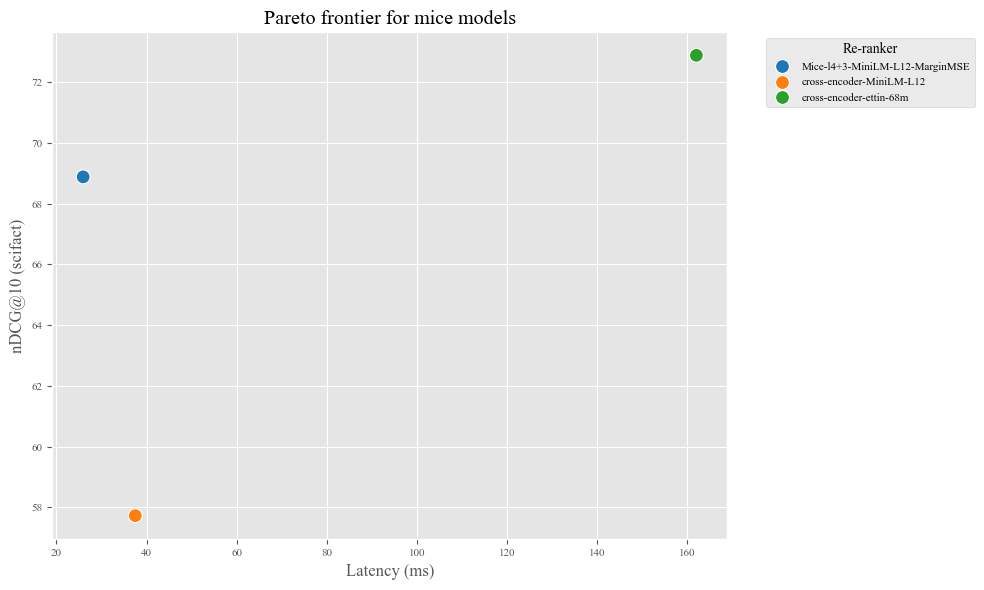

In [ ]:
metric_key = "nDCG@10"
dataset_y = "BEIR13"
dataset_y = "minified"
dataset_y = "scifact"

bench_key = "mean_time"
labels, perfs, costs = [] , [] , []
#plot performance so see correlation between performance on minified and beir13
for model in models: 
    labels.append(model.name)
    perfs.append(model.results.loc[model.results["dataset"] == dataset_y, metric_key].item())
    costs.append(model.benchmark[bench_key] * 1e3) # ms

print(labels)
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    x=costs,
    y=perfs,
    hue=labels,
    palette="tab10",
    s=100,
    ax=ax,
)
ax.set_xlabel(f"Latency (ms)")
ax.set_ylabel(f"{metric_key} ({dataset_y})")
ax.set_title(f"Pareto frontier for mice models")
plt.legend(title="Re-ranker", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"./local/figures/mice/Pareto_frontier.pdf")
plt.show()

# Analysis

## Distribution of ndcg for Mice-$\ell4$+3 v Mice-$\ell8$+3

In [ ]:
# Main table
import pandas as pd

xps = [
    "train_mice_miniLM_l4|8_ID_withruns",
    "baseline_small_CE_withruns",
    ]

dat_files = []
for xp in xps:
    xp_path = xps_root / xp
    xp_path = xps_root / xp / "dry-run"
    xp_path = get_last_xp(xps_root / xp)
    
    dat_files += list(xp_path.glob("results/models/*/evals/*.dat"))
    print(f"Using xp path: {xp_path}")
    xp_df = process_results(get_results(xp_path))

    datasets = xp_df["dataset"].unique()
    print(f"{len(datasets)} unique datasets : {list(datasets)}")
    # print(f"unique losses : {list(xp_df['loss'].unique())}")
    # print(f"Backbones : {list(xp_df['base'].unique())}")
    display(xp_df.head())
# get dat files
print(f"got {len(dat_files)} runs")

Found dates for /Users/victor/code/experiments/JZ/train_mice_miniLM_l4|8_ID_withruns: ['20260511_185945', '20260512_101811', '20260512_104719', '20260512_145819', '20260514_163608', '20260514_163808', '20260514_170228', '20260514_171539', 'current', 'dry-run', 'lock']
Using xp path: /Users/victor/code/experiments/JZ/train_mice_miniLM_l4|8_ID_withruns/20260514_171539
7 unique datasets : ['In Domain', 'mean', 'msmarco_dev', 'nfcorpus', 'touche', 'trec2019', 'trec2020']


,dataset,base,first_stage,n_contextualization_layers,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var
2,In Domain,microsoft/MiniLM-L12-H384-uncased,bm25,4.0,0.763383,0.000004,0.843083,2.112504e-05,0.625533,5.000169e-07,0.610833,8.002655e-08
3,In Domain,microsoft/MiniLM-L12-H384-uncased,bm25,8.0,0.764633,0.000016,0.841883,1.605863e-07,0.611967,7.199528e-07,0.607683,4.672236e-07
4,mean,NaN,bm25,NaN,0.625220,NaN,0.739680,NaN,0.394860,NaN,0.387080,NaN
5,mean,microsoft/MiniLM-L12-H384-uncased,bm25,4.0,0.694960,0.000018,0.806190,3.040964e-07,0.507700,2.508738e-06,0.494310,4.802046e-07
6,mean,microsoft/MiniLM-L12-H384-uncased,bm25,8.0,0.678090,0.000018,0.793540,3.175112e-06,0.494280,5.000318e-07,0.486340,1.280377e-08


Found dates for /Users/victor/code/experiments/JZ/baseline_small_CE_withruns: ['20260512_214457', 'current', 'dry-run']
Using xp path: /Users/victor/code/experiments/JZ/baseline_small_CE_withruns/20260512_214457
7 unique datasets : ['In Domain', 'mean', 'msmarco_dev', 'nfcorpus', 'touche', 'trec2019', 'trec2020']


,dataset,base,first_stage,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var
2,In Domain,jhu-clsp/ettin-encoder-68m,bm25,0.771589,0.000005,0.850756,7.025667e-07,0.645578,0.000007,0.636967,0.000003
3,In Domain,microsoft/MiniLM-L12-H384-uncased,bm25,0.769911,0.000004,0.849289,1.356734e-05,0.641422,0.000001,0.632489,0.000004
4,mean,NaN,bm25,0.625220,NaN,0.739680,NaN,0.394860,NaN,0.387080,NaN
5,mean,jhu-clsp/ettin-encoder-68m,bm25,0.696807,0.000005,0.805353,3.357340e-05,0.520027,0.000007,0.510940,0.000002
6,mean,microsoft/MiniLM-L12-H384-uncased,bm25,0.645680,0.000004,0.754113,3.041800e-05,0.483307,0.000001,0.474827,0.000007


got 25 runs


In [ ]:

names_to_ignore = ["ettin"]
runs_per_model = {}

def parse_reranker_results(file_path_or_string):
    """
    Parses a reranker result file into a pandas DataFrame.
    The file is expected to have columns: Metric, QID, Score.
    """
    # Use sep='\s+' to handle multiple spaces or tabs
    # We define the column names manually as the file has no header
    df = pd.read_csv(
        file_path_or_string, 
        sep=r'\s+', 
        names=['Metric', 'QID', 'Score'], 
        header=None
    )
    return df

for dat in dat_files:
    model_name = dat.parent.parent.name
    dataset_name = re.match(r"detailed_(.+).dat", dat.name).group(1)
    runs = runs_per_model.get(model_name,{})
    runs[dataset_name] = parse_reranker_results(dat)
    runs_per_model[model_name] = runs

runs_per_model = {k:v for k,v in runs_per_model.items() if len(v.keys())}
models = list(runs_per_model.keys())



models = [
        model_name
        for model_name in models
        if not any([pattern in model_name for pattern in names_to_ignore])
    ]

datasets = list(runs_per_model[models[0]].keys())
print(f"got runs for models: {models}")
display(runs_per_model[models[0]]["trec2019"])

got runs for models: ['Mice-l4+3-MiniLM-L12', 'Mice-l8+3-MiniLM-L12', 'cross-encoder-MiniLM-L12', 'bm25']


,Metric,QID,Score
0,nDCG@10,156493,0.9009
1,nDCG@20,156493,0.9507
2,Success@5,156493,1.0000
3,nDCG@10,1110199,0.7767
4,nDCG@20,1110199,0.6436
...,...,...,...
167,RR@10,405717,1.0000
168,RR@10,182539,1.0000
169,RR@10,1113437,1.0000
170,RR@10,1129237,1.0000


distribution for msmarco_dev


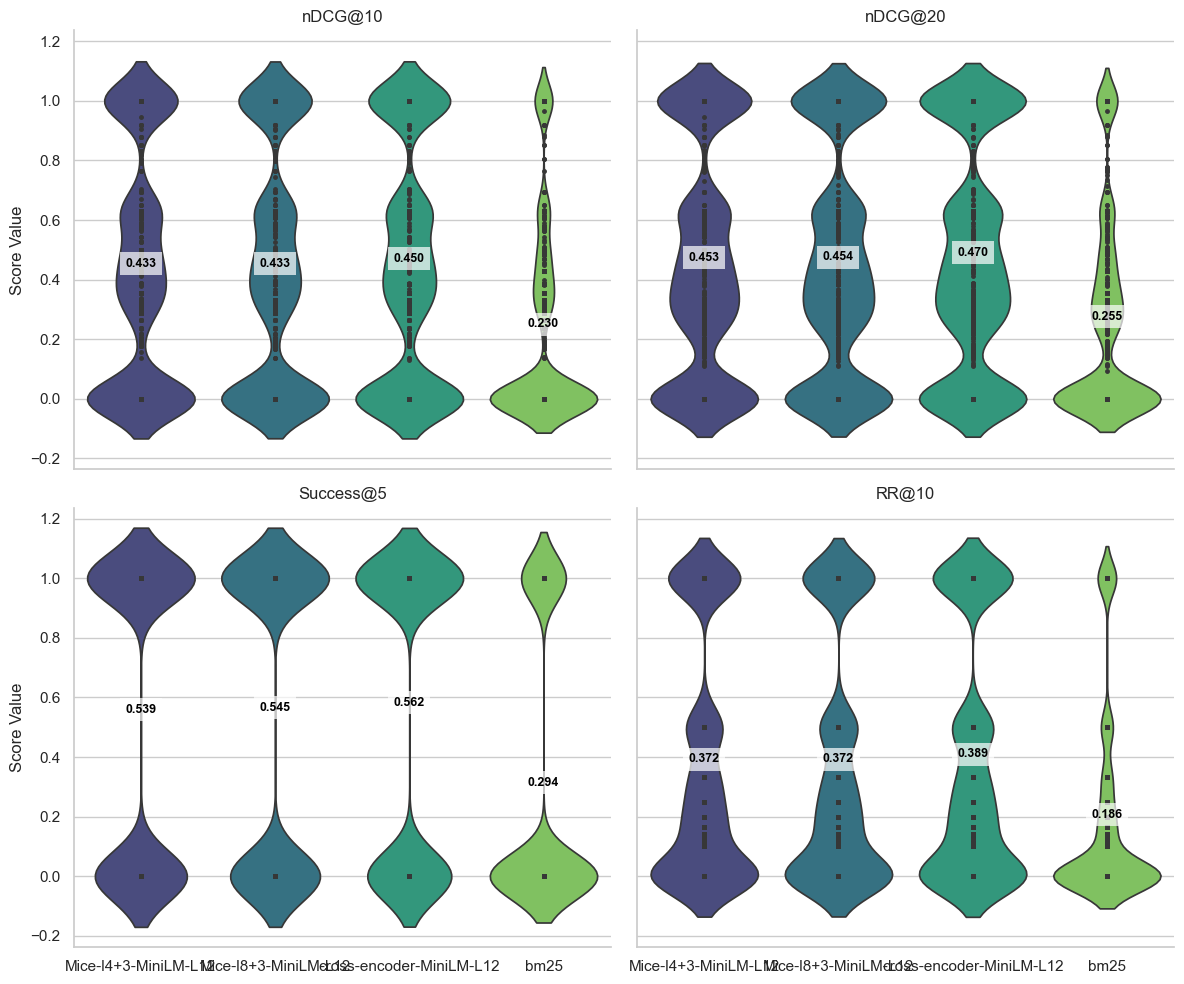

distribution for nfcorpus


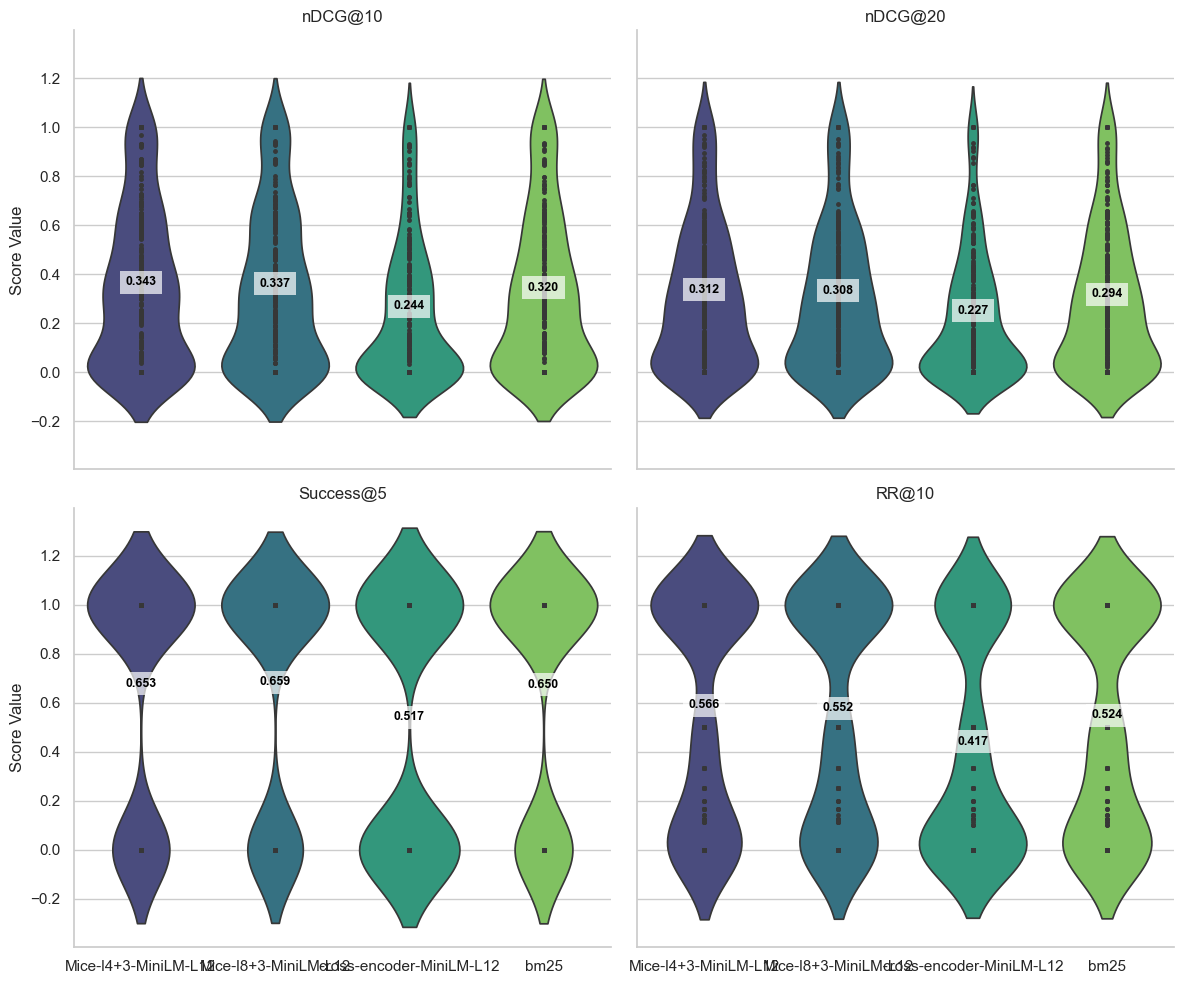

distribution for trec2019


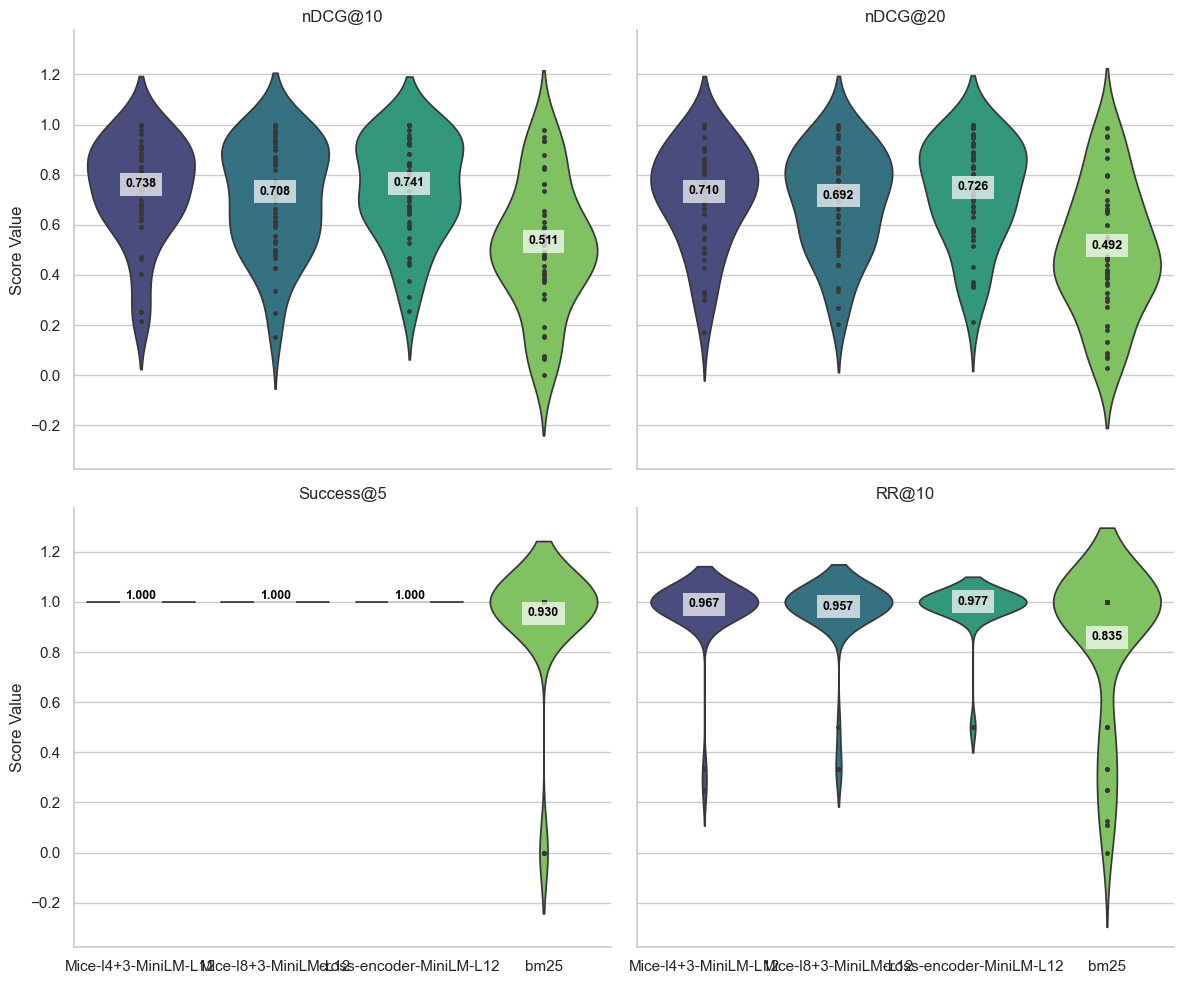

distribution for touche


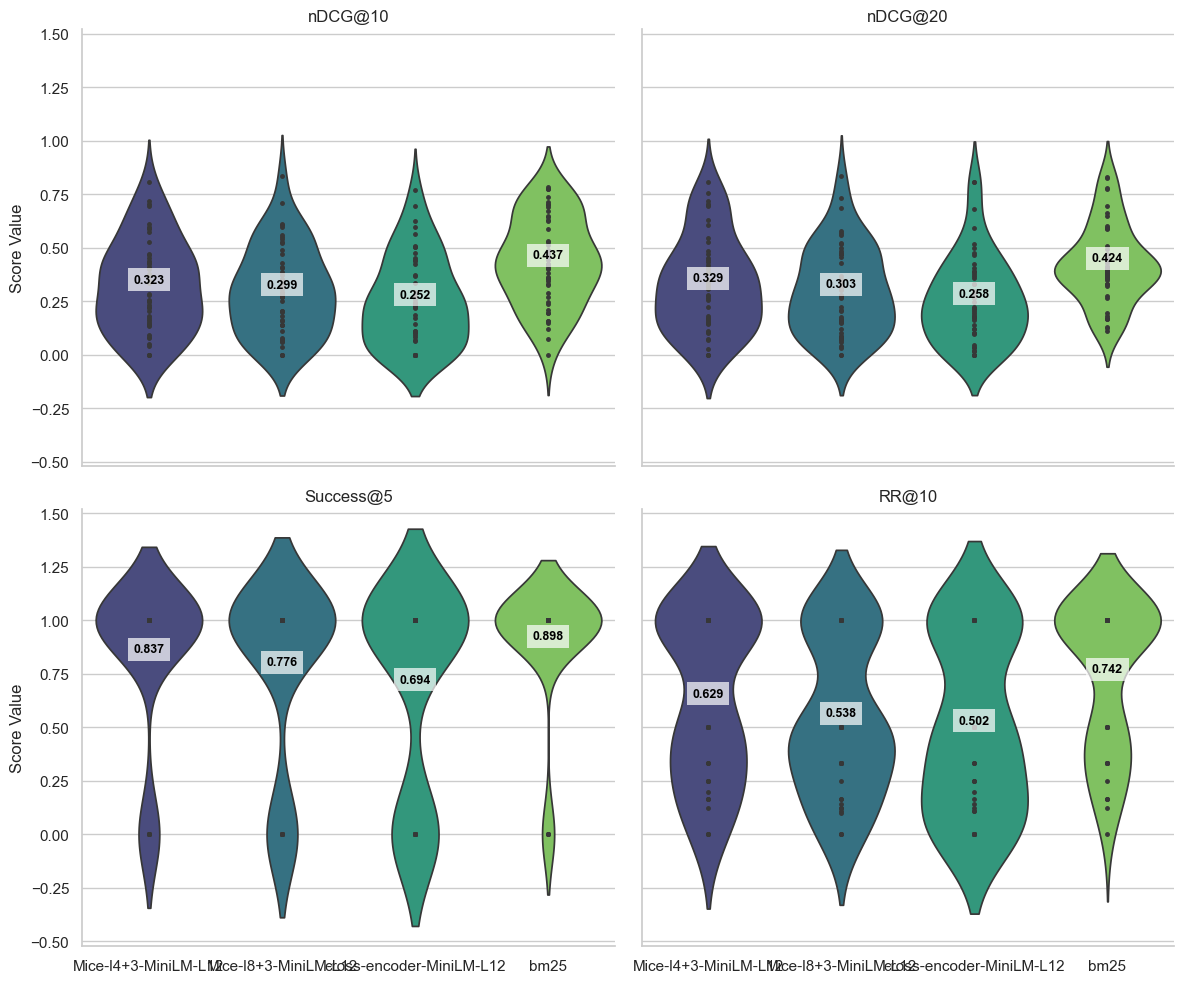

distribution for trec2020


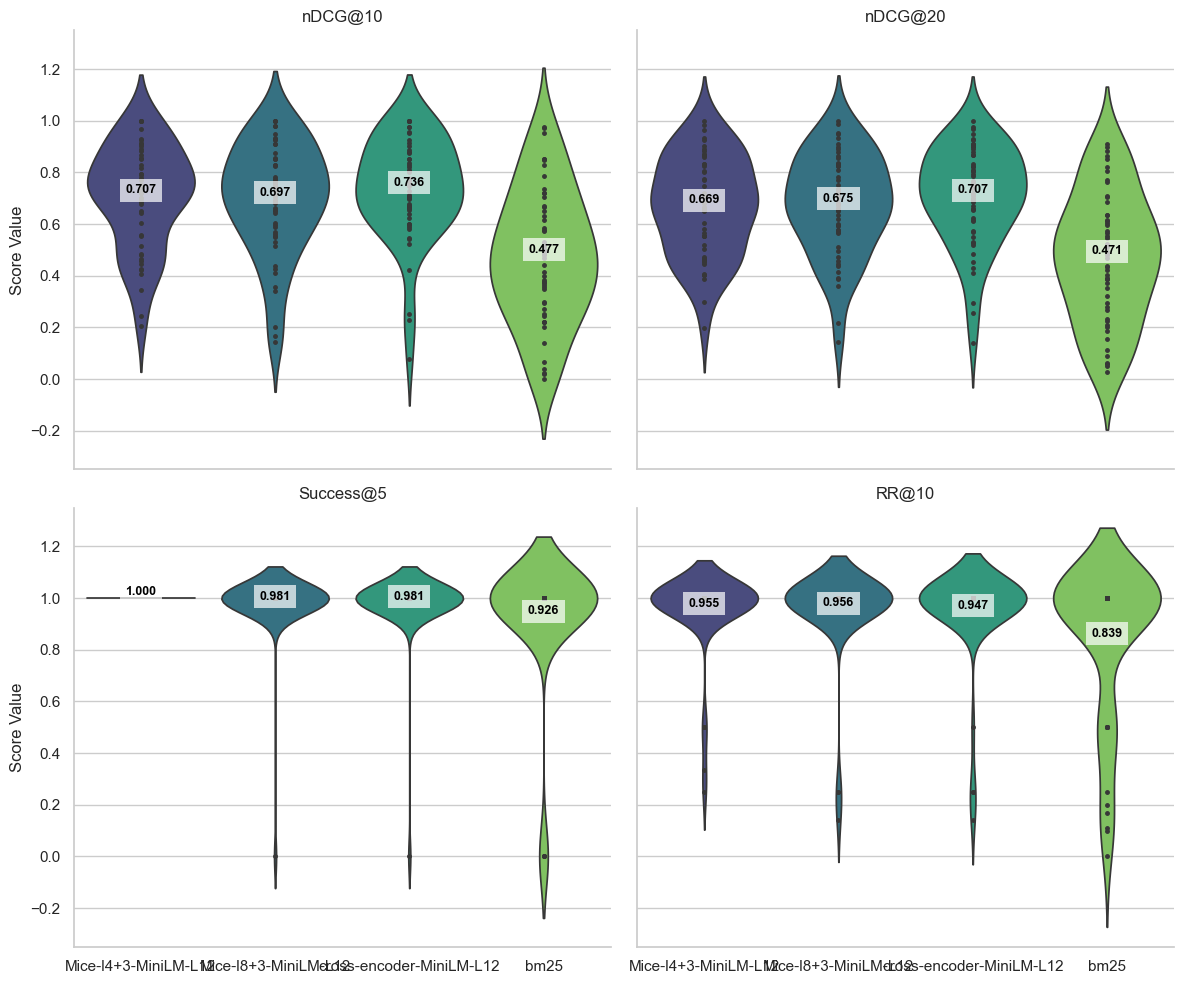

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_model_comparison(runs_per_model, dataset, models):
    all_data = []

   
    # 1. Combine data
    for model_name in models:
        df = runs_per_model[model_name][dataset].copy()
        df["Model"] = model_name
        all_data.append(df)

    combined_df = pd.concat(all_data, ignore_index=True)

    # 2. Plotting with Deprecation Fixes
    sns.set_theme(style="whitegrid")

    g = sns.catplot(
        data=combined_df,
        x="Model",
        y="Score",
        hue="Model",  # Fix: Assign x to hue
        col="Metric",
        kind="violin",
        inner="points",
        palette="viridis",
        legend=False,  # Fix: Remove redundant legend
        col_wrap=2,
        height=5,
        aspect=1.2,
        sharey=True,
    )

    # 4. Overlay Averages
    axes = g.axes.flatten()
    metrics = combined_df["Metric"].unique()

    for i, metric in enumerate(metrics):
        ax = axes[i]
        metric_data = combined_df[combined_df["Metric"] == metric]
        means = metric_data.groupby("Model", sort=False)["Score"].mean()

        for j, model_name in enumerate(models):
            avg_val = means[model_name]
            ax.text(
                j,
                avg_val,
                f"{avg_val:.3f}",
                color="black",
                ha="center",
                va="bottom",
                fontweight="bold",
                fontsize=9,
                bbox=dict(facecolor="white", alpha=0.7, lw=0),
            )

    g.set_axis_labels("", "Score Value")
    g.set_titles("{col_name}")
    plt.tight_layout()
    plt.show()


# Usage:
for dataset in datasets:
    print(f"distribution for {dataset}")
    plot_model_comparison(runs_per_model, dataset, models)

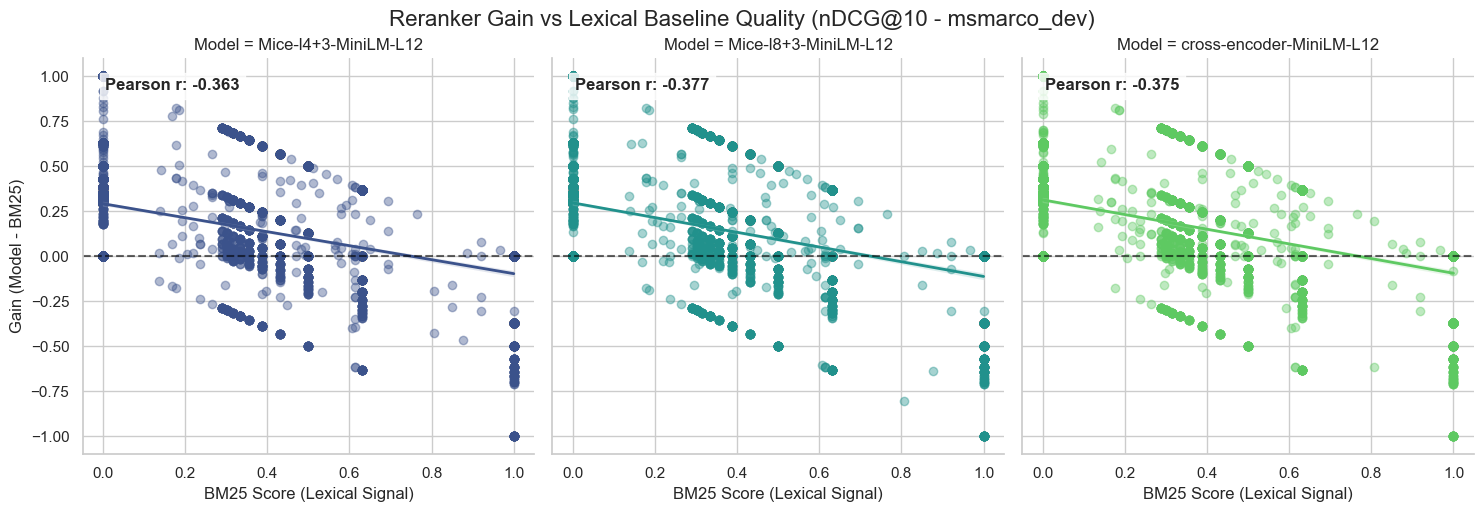

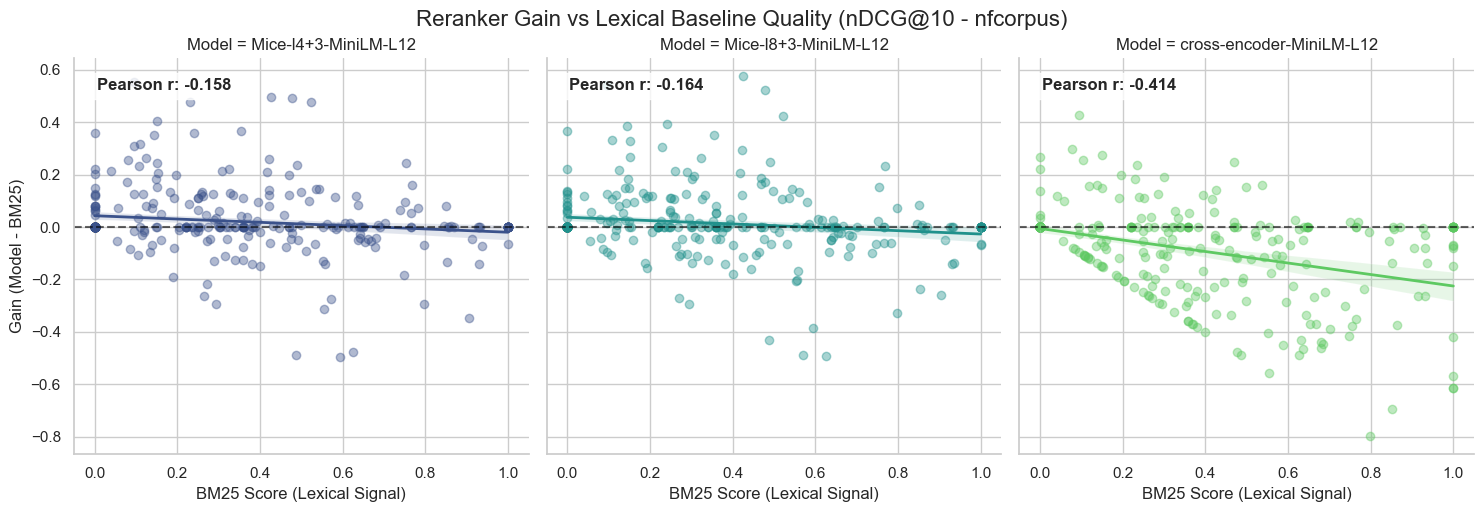

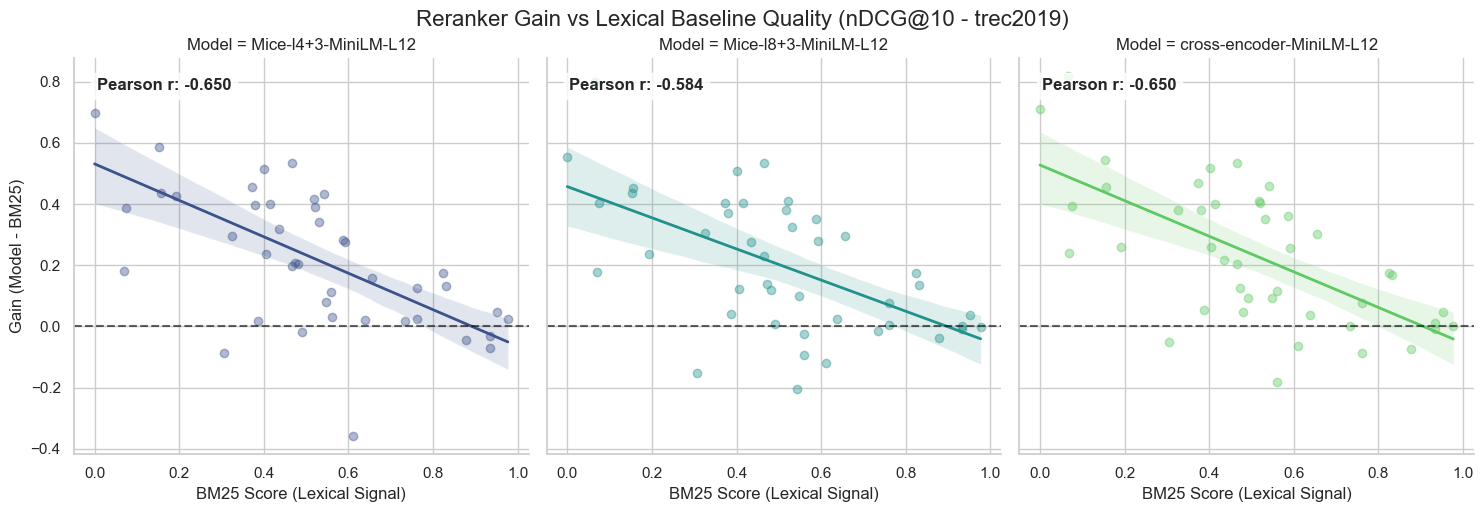

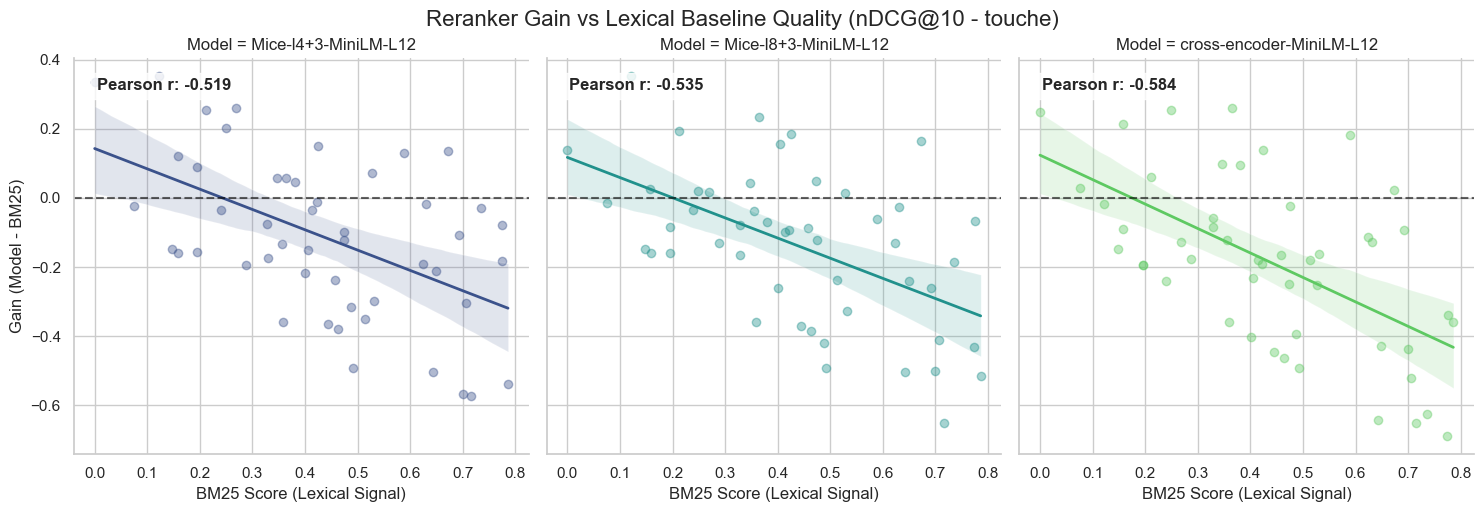

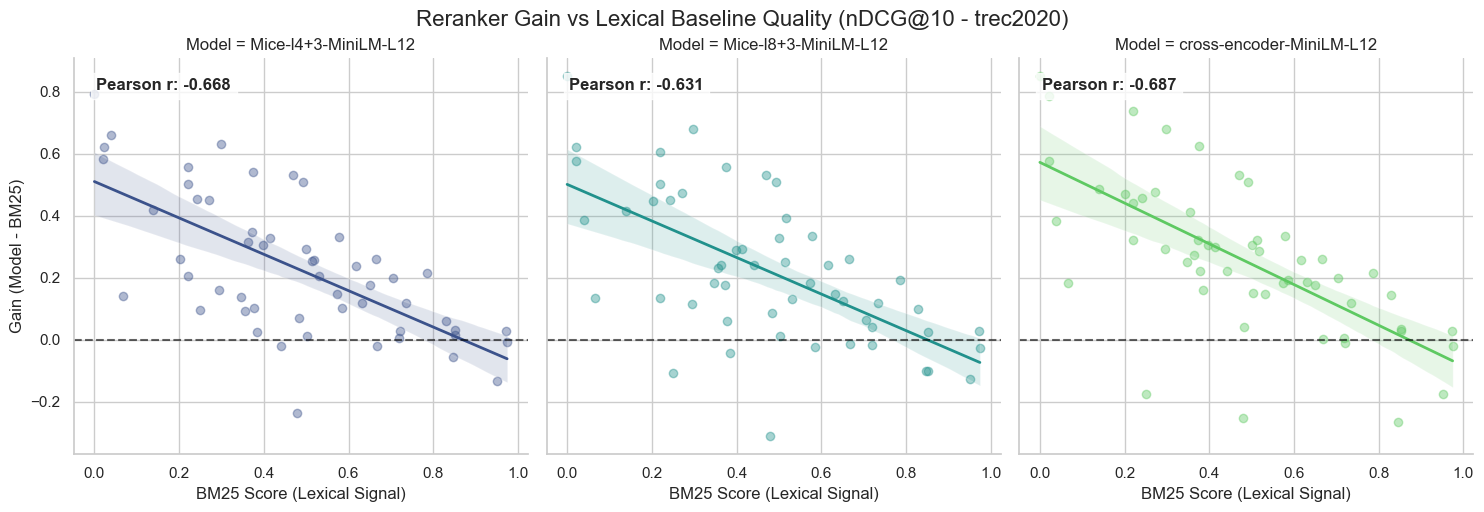

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

def plot_all_lexical_dependencies(runs_per_model, dataset, models, metric='nDCG@10'):
    all_comparisons = []
    bm25_name = 'bm25'
    
    # 1. Build a combined dataframe for all models
    df_bm25 = runs_per_model[bm25_name][dataset]
    df_bm25 = df_bm25[df_bm25['Metric'] == metric].set_index('QID')

    for model in models:
        if model == bm25_name: continue
        
        df_model = runs_per_model[model][dataset]
        df_model = df_model[df_model['Metric'] == metric].set_index('QID')
        
        temp_df = pd.DataFrame({
            'BM25 Score': df_bm25['Score'],
            'Delta': df_model['Score'] - df_bm25['Score'],
            'Model': model
        })
        all_comparisons.append(temp_df)

    combined_df = pd.concat(all_comparisons)

    # 2. Use lmplot for side-by-side regression analysis
    sns.set_theme(style="whitegrid")
    g = sns.lmplot(
        data=combined_df, 
        x='BM25 Score', 
        y='Delta', 
        col='Model', 
        hue='Model',
        palette='viridis',
        scatter_kws={'alpha': 0.4},
        line_kws={'lw': 2},
        height=5, 
        aspect=1.0,
        col_wrap=3
    )

    # 3. Add baseline and Correlation coefficients
    for model_name, ax in g.axes_dict.items():
        # Draw baseline at 0
        ax.axhline(0, color='black', linestyle='--', alpha=0.6)
        
        # Calculate correlation for this specific model
        subset = combined_df[combined_df['Model'] == model_name]
        # Drop NaNs if any exist to prevent correlation errors
        subset = subset.dropna(subset=['BM25 Score', 'Delta'])
        
        corr, _ = stats.pearsonr(subset['BM25 Score'], subset['Delta'])
        
        # Display correlation in the plot
        ax.text(0.05, 0.95, f'Pearson r: {corr:.3f}', 
                transform=ax.transAxes, verticalalignment='top',
                fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

    g.set_axis_labels("BM25 Score (Lexical Signal)", "Gain (Model - BM25)")
    g.fig.suptitle(f'Reranker Gain vs Lexical Baseline Quality ({metric} - {dataset})', y=1.02, fontsize=16)
    
    plt.show()

# Execution
for dataset in datasets:
    plot_all_lexical_dependencies(runs_per_model, dataset, models)

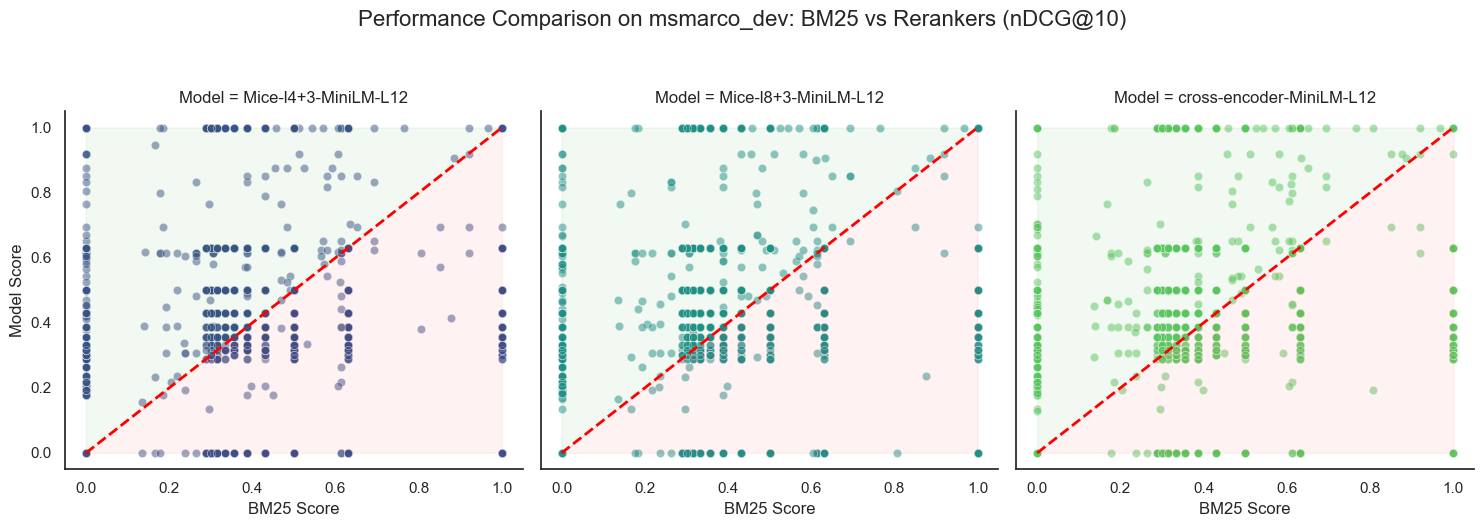

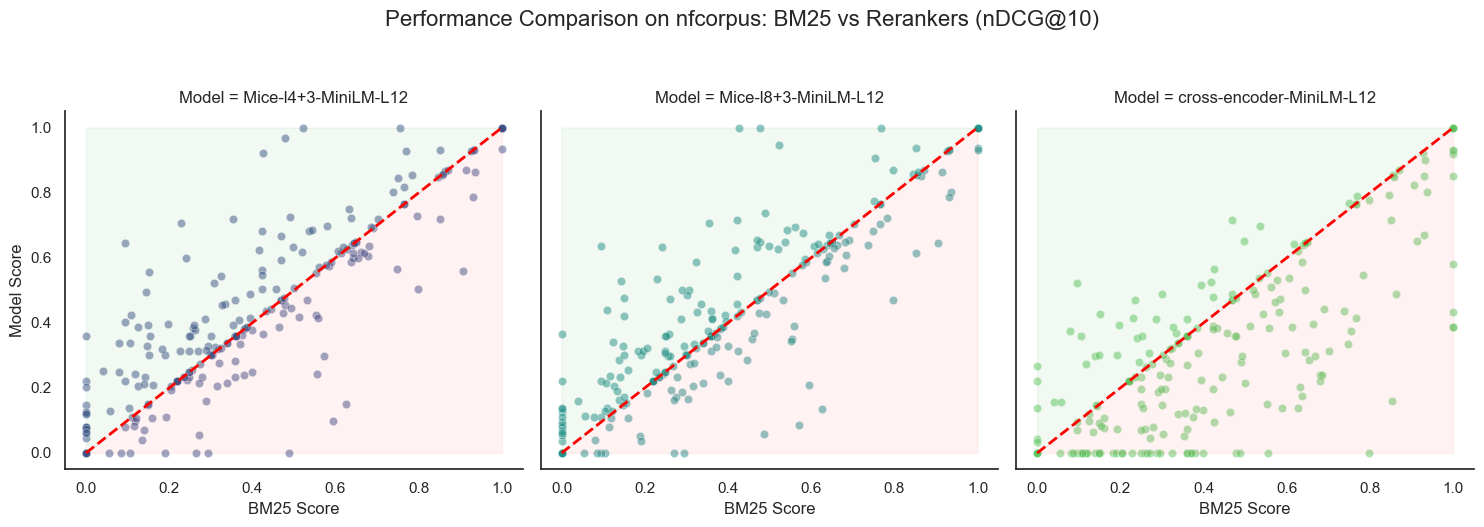

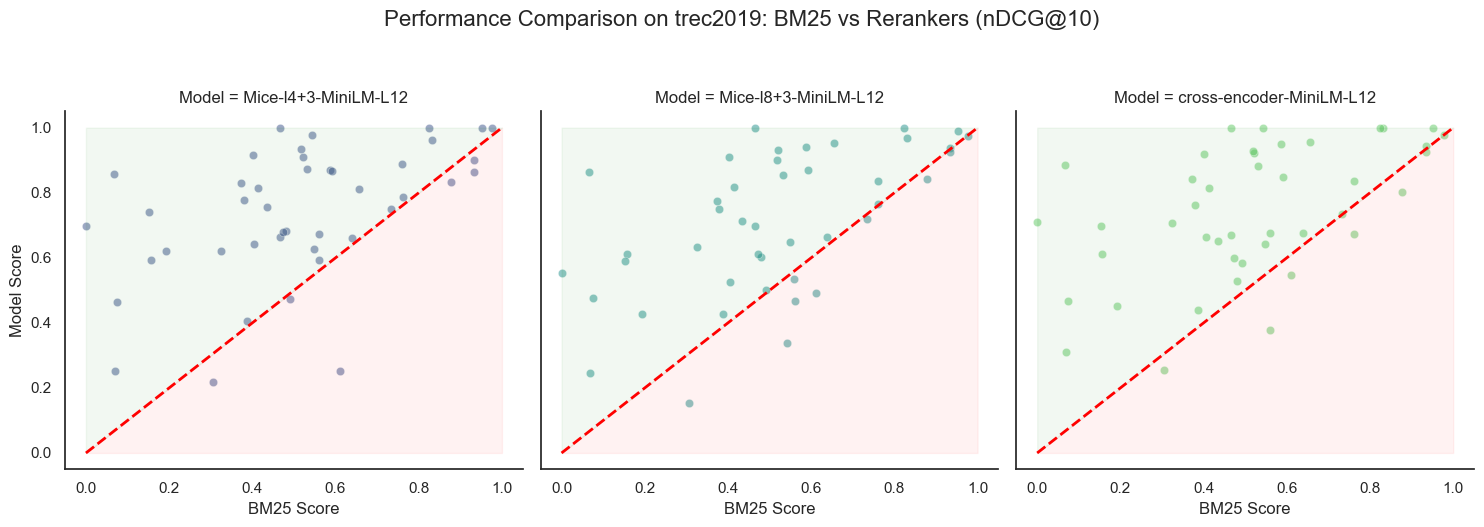

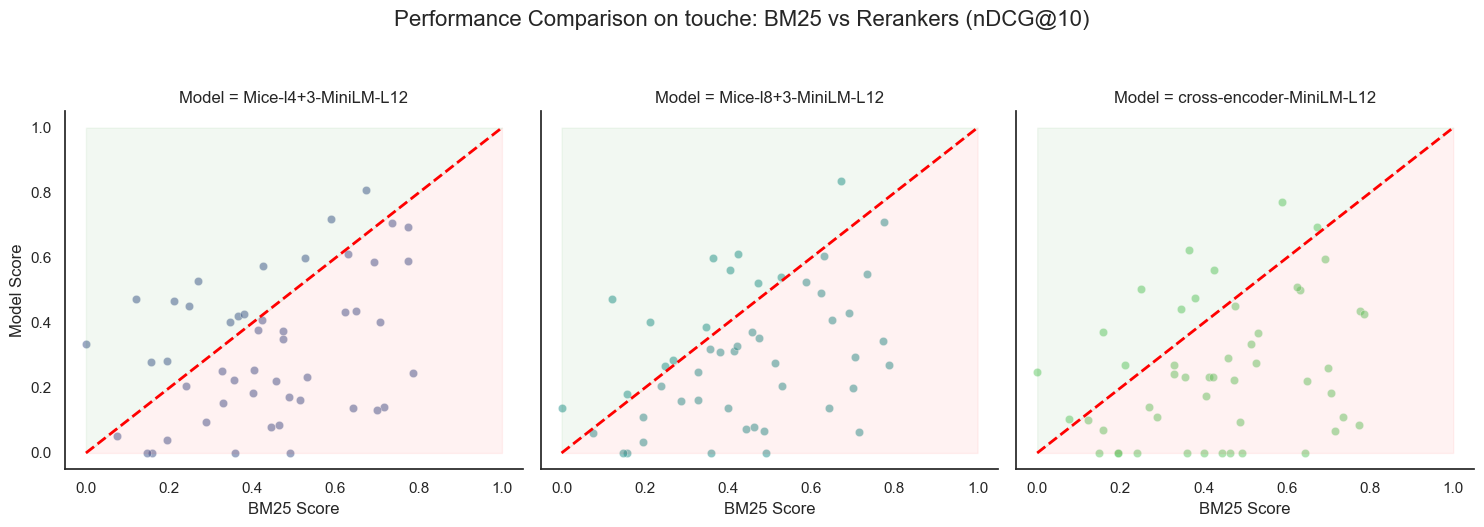

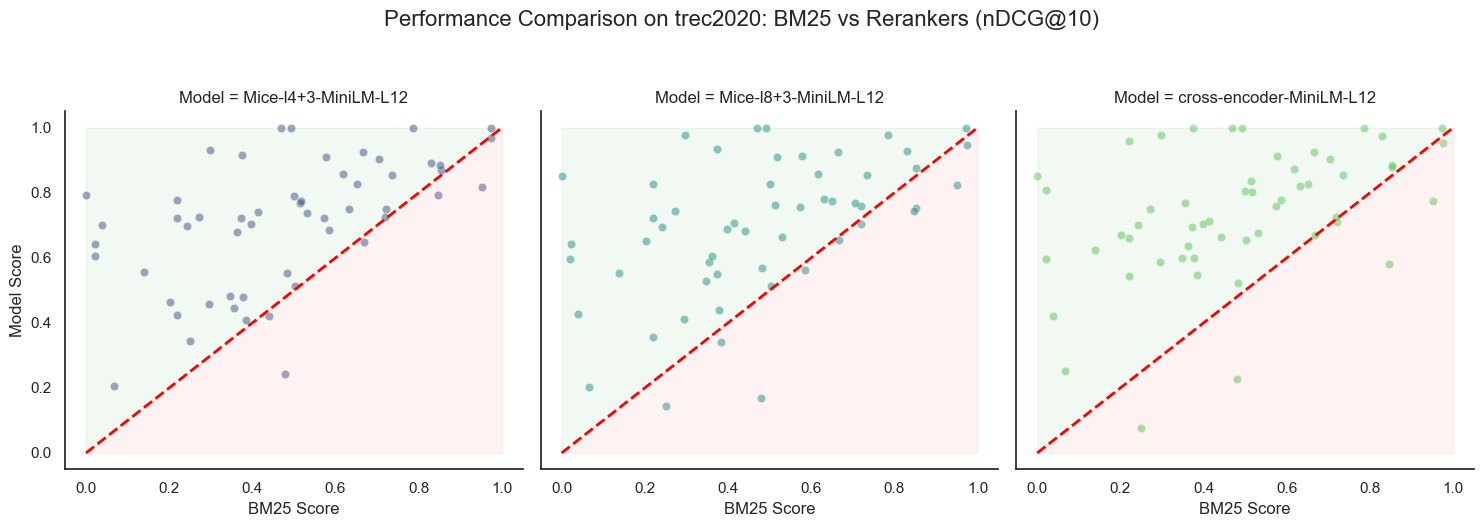

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_bm25_vs_model_direct(runs_per_model, dataset, models, metric='nDCG@10'):
    all_comparisons = []
    bm25_name = 'bm25'
    
    # 1. Get BM25 scores as the anchor
    df_bm25 = runs_per_model[bm25_name][dataset]
    df_bm25 = df_bm25[df_bm25['Metric'] == metric].set_index('QID')

    for model in models:
        if model == bm25_name: continue
        
        df_model = runs_per_model[model][dataset]
        df_model = df_model[df_model['Metric'] == metric].set_index('QID')
        
        temp_df = pd.DataFrame({
            'BM25 Score': df_bm25['Score'],
            'Model Score': df_model['Score'],
            'Model': model
        })
        all_comparisons.append(temp_df)

    combined_df = pd.concat(all_comparisons)

    # 2. Plotting
    sns.set_theme(style="white")
    g = sns.FacetGrid(combined_df, col="Model", hue="Model", 
                      palette='viridis', height=5, aspect=1, col_wrap=3)

    # Use regplot but disable the regression line if you just want the raw scatter, 
    # or keep it to see the general trend.
    g.map(sns.scatterplot, 'BM25 Score', 'Model Score', alpha=0.5)

    # 3. Add the Identity Line (y=x)
    for ax in g.axes.flatten():
        # Draw a 45-degree dashed line from (0,0) to (1,1)
        ax.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=2, label='Identity (y=x)')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        
        # Optional: Count how many queries are above/below the line
        # This gives a quick "Win Rate" visual
        ax.fill_between([0, 1], [0, 1], 1, color='green', alpha=0.05) # "Model Win" zone
        ax.fill_between([0, 1], 0, [0, 1], color='red', alpha=0.05)   # "BM25 Win" zone

    g.set_axis_labels("BM25 Score", "Model Score")
    g.figure.suptitle(f'Performance Comparison on {dataset}: BM25 vs Rerankers ({metric})', y=1.05, fontsize=16)
    
    plt.tight_layout()
    plt.show()

# plot_bm25_vs_model_direct(runs_per_model, "trec2020", models)
# Execution
for dataset in datasets:
    plot_bm25_vs_model_direct(runs_per_model, dataset, models)

# Ablations

## Booleans Ablation

In [ ]:
# Main table
import pandas as pd
from IPython.display import display, HTML

xps = [
    "train_mice_miniLM_bools",
]


def get_tag(tagspath: str, regex: str) -> dict:
    match = re.search(regex, tagspath)
    if match:
        return match.group(1)
    return None


raw_dfs = []
for xp in xps:
    xp_path = xps_root / xp / "dry-run"
    raw_dfs.append(process_results(get_results(xp_path)))

df = pd.concat(raw_dfs)


# Define regex patterns for tags
tags = {
    "base": r"base=(.*)_global",
    "global_cls_token": r"global_cls_token=(.*)_mask_cls_to_doc",
    "mask_query_to_cls": r"mask_query_to_cls=(.*)_loss",
    "mask_cls_to_doc": r"mask_cls_to_doc=(.*)_mask",
}

# rm row without "scorer" tag
df = df[df["scorer"].notna()]
# Split "scorer" into separate columns using the regex patterns
for tag_name, pattern in tags.items():
    df[tag_name] = df["scorer"].apply(lambda x: get_tag(x, pattern))


# Ensure the boolean columns are boolean type
bool_cols = ["global_cls_token", "mask_query_to_cls", "mask_cls_to_doc"]
for col in bool_cols:
    df[col] = df[col].map({"True": True, "False": False})

datasets = list(df["dataset"].unique())
print(f"{len(datasets)} unique datasets : {datasets}")
# print(f"unique losses : {list(df["loss"].unique())}")
# print(f"Backbones : {list(df["base"].unique())}")


display(HTML(df.iloc[0:5].to_html()))

9 unique datasets : ['Mean In Domain', 'fiqa', 'mean', 'msmarco_dev', 'nfcorpus', 'scifact', 'touche', 'trec2019', 'trec2020']


,dataset,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var,first_stage,scorer,base,global_cls_token,mask_query_to_cls,mask_cls_to_doc
3,Mean In Domain,0.767267,2.837472e-05,0.842783,2.380488e-05,0.626333,4.908775e-06,0.612717,1.168059e-05,bm25,base=microsoft/MiniLM-L12-H384-uncased_global_cls_token=False_mask_cls_to_doc=False_mask_query_to_cls=False_loss=marginMSE,microsoft/MiniLM-L12-H384-uncased,False,False,False
4,Mean In Domain,0.768283,1.560529e-06,0.846000,0.000000e+00,0.626450,9.338594e-07,0.613767,3.555358e-06,bm25,base=microsoft/MiniLM-L12-H384-uncased_global_cls_token=False_mask_cls_to_doc=False_mask_query_to_cls=True_loss=marginMSE,microsoft/MiniLM-L12-H384-uncased,False,True,False
5,Mean In Domain,0.758600,4.999275e-07,0.843983,1.027278e-06,0.619367,1.494240e-05,0.608267,1.351999e-05,bm25,base=microsoft/MiniLM-L12-H384-uncased_global_cls_token=False_mask_cls_to_doc=True_mask_query_to_cls=False_loss=marginMSE,microsoft/MiniLM-L12-H384-uncased,False,False,True
6,Mean In Domain,0.759467,1.682005e-05,0.837083,5.570655e-10,0.617517,3.466987e-06,0.603983,2.800545e-06,bm25,base=microsoft/MiniLM-L12-H384-uncased_global_cls_token=False_mask_cls_to_doc=True_mask_query_to_cls=True_loss=marginMSE,microsoft/MiniLM-L12-H384-uncased,False,True,True
7,Mean In Domain,0.758700,5.780196e-06,0.838750,3.472464e-07,0.624617,9.392436e-08,0.613217,7.605629e-07,bm25,base=microsoft/MiniLM-L12-H384-uncased_global_cls_token=True_mask_cls_to_doc=False_mask_query_to_cls=False_loss=marginMSE,microsoft/MiniLM-L12-H384-uncased,True,False,False


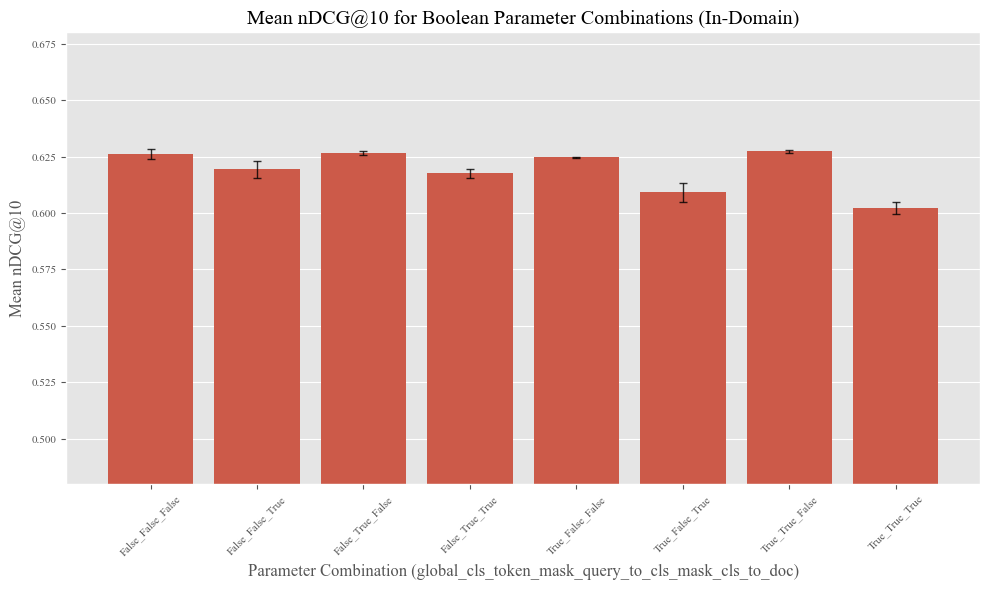

,global_cls_token,mask_query_to_cls,mask_cls_to_doc,mean_nDCG,mean_var,std_nDCG,combination
0,False,False,False,0.626333,4.908775e-06,0.002216,False_False_False
1,False,False,True,0.619367,1.494240e-05,0.003866,False_False_True
2,False,True,False,0.626450,9.338594e-07,0.000966,False_True_False
3,False,True,True,0.617517,3.466987e-06,0.001862,False_True_True
4,True,False,False,0.624617,9.392436e-08,0.000306,True_False_False
5,True,False,True,0.609117,1.820036e-05,0.004266,True_False_True
6,True,True,False,0.627283,5.338608e-07,0.000731,True_True_False
7,True,True,True,0.602150,6.600400e-06,0.002569,True_True_True


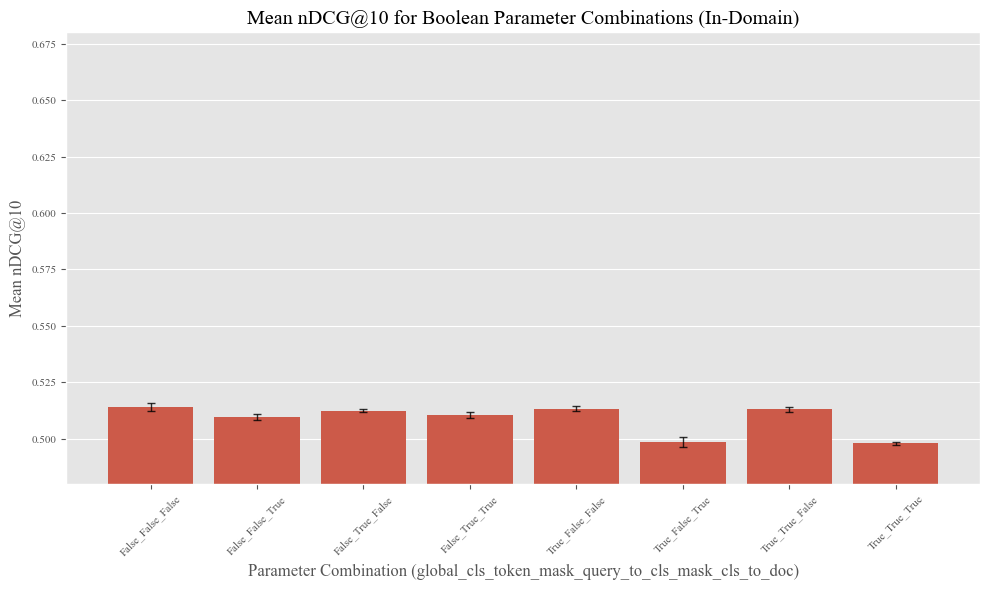

,global_cls_token,mask_query_to_cls,mask_cls_to_doc,mean_nDCG,mean_var,std_nDCG,combination
0,False,False,False,0.514000,2.948883e-06,0.001717,False_False_False
1,False,False,True,0.509779,2.086638e-06,0.001445,False_False_True
2,False,True,False,0.512550,2.449979e-07,0.000495,False_True_False
3,False,True,True,0.510393,1.751026e-06,0.001323,False_True_True
4,True,False,False,0.513407,1.594301e-06,0.001263,True_False_False
5,True,False,True,0.498457,5.028981e-06,0.002243,True_False_True
6,True,True,False,0.513157,1.103660e-06,0.001051,True_True_False
7,True,True,True,0.498000,4.718444e-07,0.000687,True_True_True


In [ ]:
# Plot in-domain nDCG@10_mean for each combination of boolean params

import matplotlib.pyplot as plt

for dataset in ["Mean In Domain", "mean"]:
    # Filter for in-domain dataset (assuming msmarco_dev is in-domain)
    in_domain_df = df[df["dataset"] == dataset].copy()

    # Group by the boolean combinations and compute mean of nDCG@10_mean and mean of nDCG@10_var
    grouped = (
        in_domain_df.groupby(bool_cols)
        .agg(mean_nDCG=("nDCG@10_mean", "mean"), mean_var=("nDCG@10_var", "mean"))
        .reset_index()
    )

    # Compute std as sqrt of mean variance
    grouped["std_nDCG"] = np.sqrt(grouped["mean_var"])

    # Create a combination label
    grouped["combination"] = grouped[bool_cols].astype(str).agg("_".join, axis=1)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = sns.barplot(data=grouped, x="combination", y="mean_nDCG", ax=ax)
    ax.errorbar(
        x=range(len(grouped)),
        y=grouped["mean_nDCG"],
        yerr=grouped["std_nDCG"],
        fmt="none",
        c="black",
        capsize=3,
        elinewidth=1,
        alpha=0.8,
    )
    ax.set_title("Mean nDCG@10 for Boolean Parameter Combinations (In-Domain)")
    ax.set_xlabel(
        "Parameter Combination (global_cls_token_mask_query_to_cls_mask_cls_to_doc)"
    )
    ax.set_ylabel("Mean nDCG@10")
    plt.xticks(rotation=45)
    plt.ylim(0.48, 0.68)
    plt.tight_layout()
    plt.show()

    # Display the grouped data
    display(grouped)

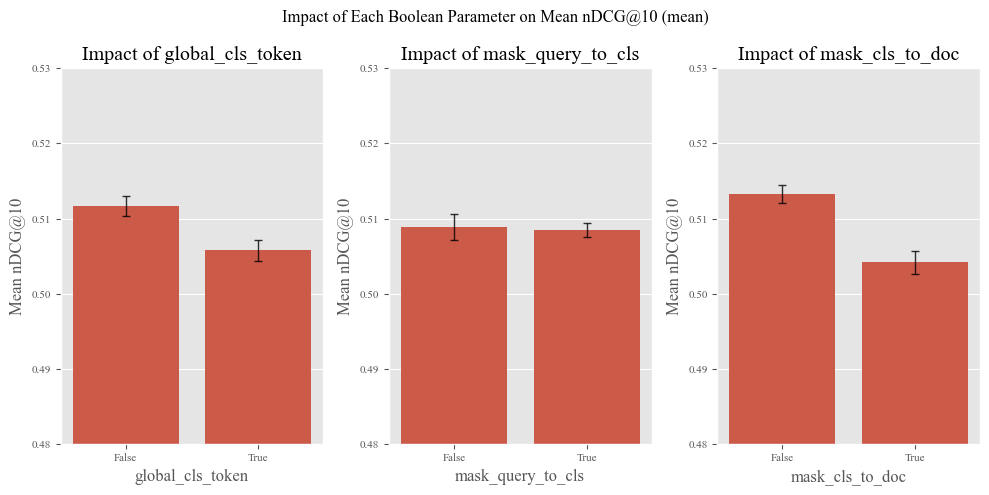

In [ ]:
# Plot impact of each boolean parameter separately

# Create subplots for each boolean parameter
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
fig.suptitle(
    "Impact of Each Boolean Parameter on Mean nDCG@10 ({dataset})".format(
        dataset=dataset
    )
)

grouped_dfs = []
for ax, param in zip(axes, bool_cols):
    grouped = (
        in_domain_df.groupby(param)
        .agg(mean_nDCG=("nDCG@10_mean", "mean"), mean_var=("nDCG@10_var", "mean"))
        .reset_index()
    )
    grouped["std_nDCG"] = np.sqrt(grouped["mean_var"])

    sns.barplot(data=grouped, x=param, y="mean_nDCG", ax=ax)
    ax.errorbar(
        x=range(len(grouped)),
        y=grouped["mean_nDCG"],
        yerr=grouped["std_nDCG"],
        fmt="none",
        c="black",
        capsize=3,
        elinewidth=1,
        alpha=0.8,
    )
    ax.set_title(f"Impact of {param}")
    ax.set_xlabel(param)
    ax.set_ylabel("Mean nDCG@10")
    ax.set_ylim(0.48, 0.53)

    grouped_dfs.append(grouped)

plt.tight_layout()
plt.show()

## Mice MiniLM X+3 - Vanilla vs Inverted

In [ ]:
# Main table
import pandas as pd

xps = {
    "train_mice_miniLM_lX+3": "Inverted Cross-Self Attn",
    "train_mice_miniLM_lX+3_vanilla": "Vanilla Self-Cross Attn",
}


def get_xp_df(xp):
    xp_path = xps_root / xp / "dry-run"
    xp_path = get_last_xp(xps_root / xp)
    xp_path = xps_root / xp / "20260425_161300" #
    if 'vanilla' in xp: 
        xp_path = get_last_xp(xps_root / xp)
    else:
        xp_path = xps_root / xp / "20260425_161300" #
        xp_path = get_last_xp(xps_root / xp)
    print(f"Using xp path: {xp_path}")
    df = process_results(get_results(xp_path))

    datasets = df["dataset"].unique()
    print(f"{len(datasets)} unique datasets : {list(datasets)}")
    # print(f"unique losses : {list(df['loss'].unique())}")
    # print(f"Backbones : {list(df['base'].unique())}")

    display(df.head())
    return df

xp_dfs = {xp: get_xp_df(xp) for xp in xps.keys()}

Found dates for /Users/victor/code/experiments/JZ/train_mice_miniLM_lX+3: ['20260424_143839', '20260425_161300', '20260512_215807', '20260513_085811', '20260513_093201', 'current', 'lock']
Found dates for /Users/victor/code/experiments/JZ/train_mice_miniLM_lX+3: ['20260424_143839', '20260425_161300', '20260512_215807', '20260513_085811', '20260513_093201', 'current', 'lock']
Using xp path: /Users/victor/code/experiments/JZ/train_mice_miniLM_lX+3/20260513_093201
5 unique datasets : ['In Domain', 'mean', 'msmarco_dev', 'trec2019', 'trec2020']


,dataset,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var,base,first_stage,n_contextualization_layers
2,In Domain,0.62006664,NaN,0.7167333,NaN,0.40583333,NaN,0.40576664,NaN,NaN,bm25,NaN
3,In Domain,0.7280777,1.4114847e-06,0.8224667,1.3663354e-05,0.55876666,6.601004e-06,0.5579445,1.0670453e-06,microsoft/MiniLM-L12-H384-uncased,bm25,0
4,In Domain,0.7379778,1.9640476e-05,0.82625556,2.223799e-06,0.58382225,9.971361e-06,0.5800333,4.407645e-06,microsoft/MiniLM-L12-H384-uncased,bm25,1
5,In Domain,0.75412226,3.973603e-06,0.84076667,6.300482e-07,0.60194445,1.1077915e-05,0.59511113,7.071646e-06,microsoft/MiniLM-L12-H384-uncased,bm25,2
6,In Domain,0.7584222,9.2294285e-06,0.83955556,1.4446058e-05,0.61396664,1.1811496e-06,0.60326666,1.8777122e-07,microsoft/MiniLM-L12-H384-uncased,bm25,3


Found dates for /Users/victor/code/experiments/JZ/train_mice_miniLM_lX+3_vanilla: ['20260421_083259', 'current', 'dry-run']
Found dates for /Users/victor/code/experiments/JZ/train_mice_miniLM_lX+3_vanilla: ['20260421_083259', 'current', 'dry-run']
Using xp path: /Users/victor/code/experiments/JZ/train_mice_miniLM_lX+3_vanilla/20260421_083259
9 unique datasets : ['Mean In Domain', 'fiqa', 'mean', 'msmarco_dev', 'nfcorpus', 'scifact', 'touche', 'trec2019', 'trec2020']


,dataset,RR@10_mean,RR@10_var,Success@5_mean,Success@5_var,nDCG@10_mean,nDCG@10_var,nDCG@20_mean,nDCG@20_var,base,first_stage,loss,n_contextualization_layers
2,Mean In Domain,0.62006664,NaN,0.7167333,NaN,0.40583333,NaN,0.40576664,NaN,NaN,bm25,NaN,NaN
3,Mean In Domain,0.72519994,1.2500125e-05,0.8211833,8.449705e-07,0.55355,8.449705e-07,0.5492667,1.8688369e-06,microsoft/MiniLM-L12-H384-uncased,bm25,marginMSE,0
4,Mean In Domain,0.74445,3.827393e-06,0.83265,5.570655e-10,0.5837167,8.133864e-06,0.5800834,6.6006164e-06,microsoft/MiniLM-L12-H384-uncased,bm25,marginMSE,1
5,Mean In Domain,0.7535167,0.00019933439,0.8358167,4.640026e-05,0.5945,5.7602574e-05,0.5893,6.346936e-05,microsoft/MiniLM-L12-H384-uncased,bm25,marginMSE,2
6,Mean In Domain,0.75285006,6.1252595e-06,0.83924997,5.894242e-06,0.61195,6.1249466e-06,0.5997667,3.919966e-06,microsoft/MiniLM-L12-H384-uncased,bm25,marginMSE,3


No data found for dataset: Mean In Domain


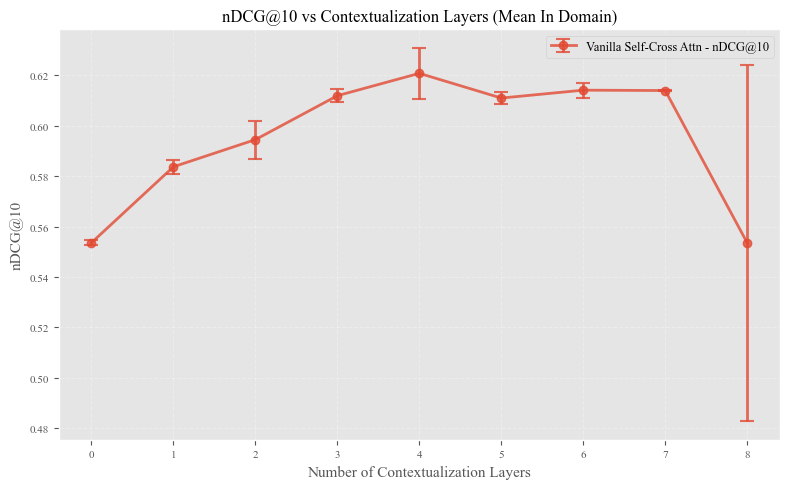


Aggregated nDCG@10 Statistics by Contextualization Layers (Mean In Domain):


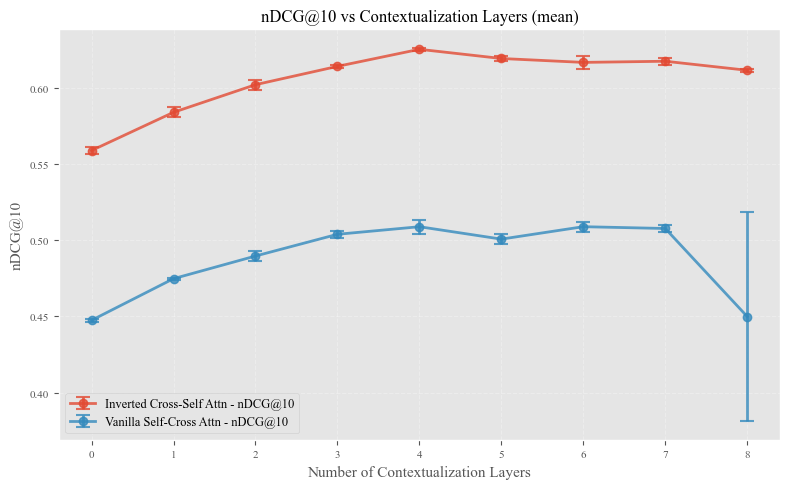


Aggregated nDCG@10 Statistics by Contextualization Layers (mean):


In [ ]:
#filter 'n_contextualization_layers' is not null
metric = "nDCG@10"
metric_mean = f"{metric}_mean"
metric_var = f"{metric}_var"

# Plot for each dataset
for dataset_name in ["Mean In Domain", "mean"]:
    # Create figure with publication quality
    fig, ax = plt.subplots(figsize=(8, 5))

    for xp, df in xp_dfs.items():
        # plot nDCG@10_mean /pm nDCG@10_var as a function of n_contextualization_layers
        df["n_contextualization_layers"] = pd.to_numeric(df["n_contextualization_layers"], errors="coerce")
        df[metric_mean] = pd.to_numeric(df[metric_mean], errors="coerce")
        df[metric_var] = pd.to_numeric(df[metric_var], errors="coerce")
        df = df[df["n_contextualization_layers"].notnull()]
        dataset_df = df[df["dataset"] == dataset_name].copy()
        if len(dataset_df) == 0:
            print(f"No data found for dataset: {dataset_name}")
            continue
        
        # Group by n_contextualization_layers and compute aggregated statistics
        grouped = dataset_df.groupby("n_contextualization_layers", dropna=False).agg(
            mean_nDCG=(metric_mean, "mean"),
            std_nDCG=(metric_var, lambda x: np.sqrt(x.mean())),  # sqrt of mean variance
            count=(metric_mean, "count")
        ).reset_index()

        grouped = grouped.sort_values("n_contextualization_layers")

        ax.errorbar(
            grouped["n_contextualization_layers"],
            grouped["mean_nDCG"],
            yerr=grouped["std_nDCG"],
            fmt="o-",
            markersize=6,
            linewidth=2,
            capsize=5,
            capthick=1.5,
            # color="#1f77b4",
            # ecolor="#1f77b4",
            alpha=0.8,
            label=f"{xps[xp]} - {metric}"
        )

    # Formatting
    ax.set_xlabel("Number of Contextualization Layers", fontsize=11, fontweight="normal")
    ax.set_ylabel("nDCG@10", fontsize=11, fontweight="normal")
    ax.set_title(f"{metric} vs Contextualization Layers ({dataset_name})", fontsize=12, fontweight="normal")
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.legend(frameon=True, loc="best", fontsize=9)
    ax.set_xticks(grouped["n_contextualization_layers"].unique())
    # ax.set_ylim(.50, .512)  # nDCG is between 0 and 1
    plt.tight_layout()
    plt.savefig(fig_dir / f"nDCG10_vs_ContextLayers_{dataset_name.replace(' ', '_')}_vs_vanilla.pdf")
    plt.show()
    # Display grouped results
    print(f"\nAggregated nDCG@10 Statistics by Contextualization Layers ({dataset_name}):")
        # display(grouped)